### The Goal
Play [Hollowknight: Silksong](https://store.steampowered.com/app/1030300/Hollow_Knight_Silksong/) with gestures.

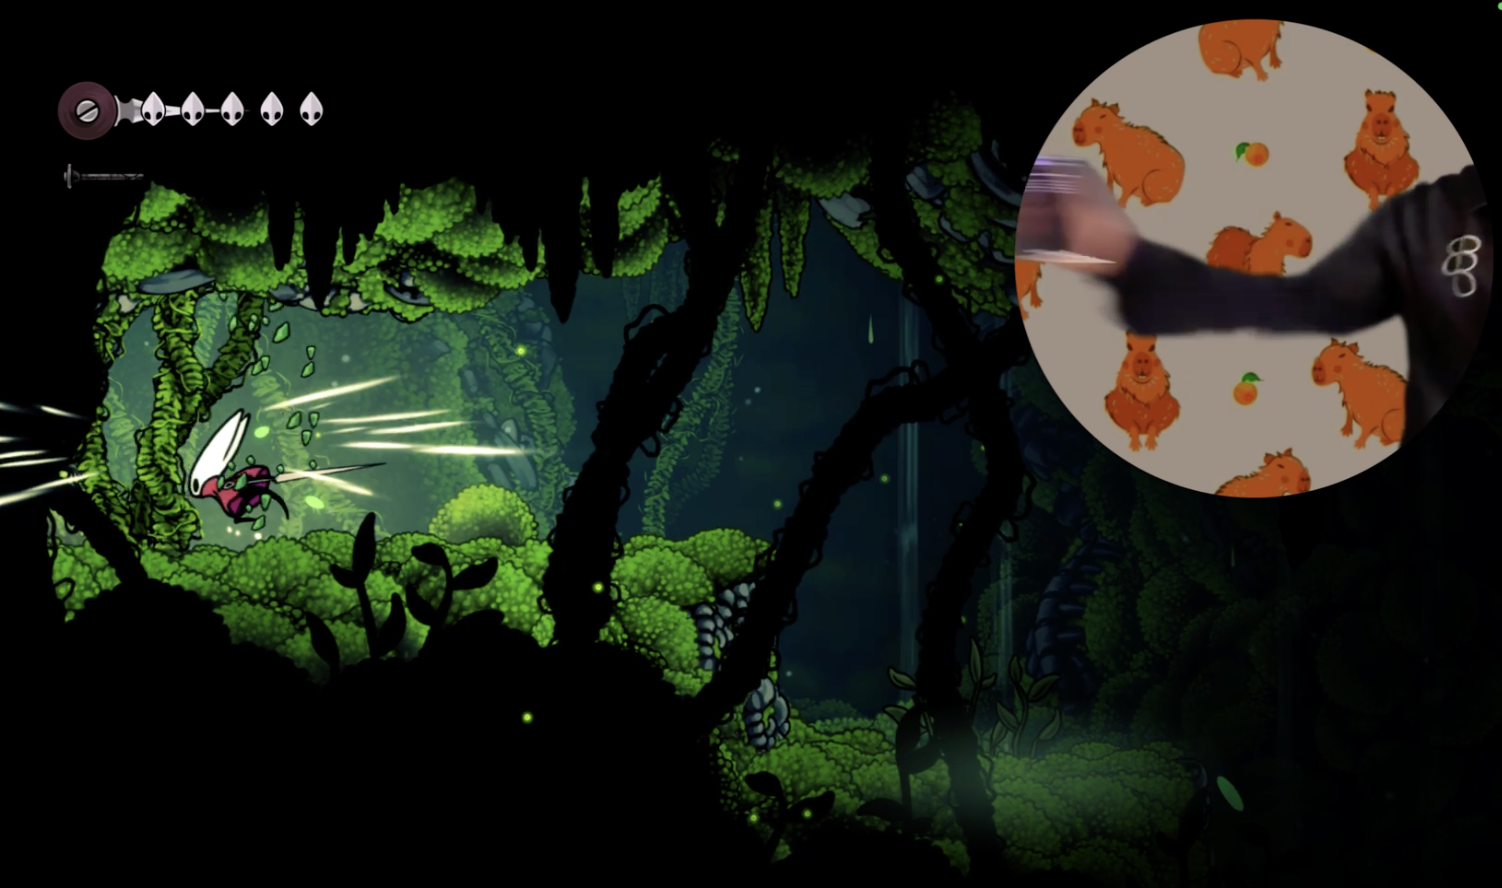


### **Section 1: Data Explanation**

#### 1.1 "What is included?"

Personal dataset of raw, 50Hz, 9-axis sensor, Inertial Measurement Unit (IMU) signals from a [Pixel Watch](https://support.google.com/googlepixelwatch/answer/12651869): 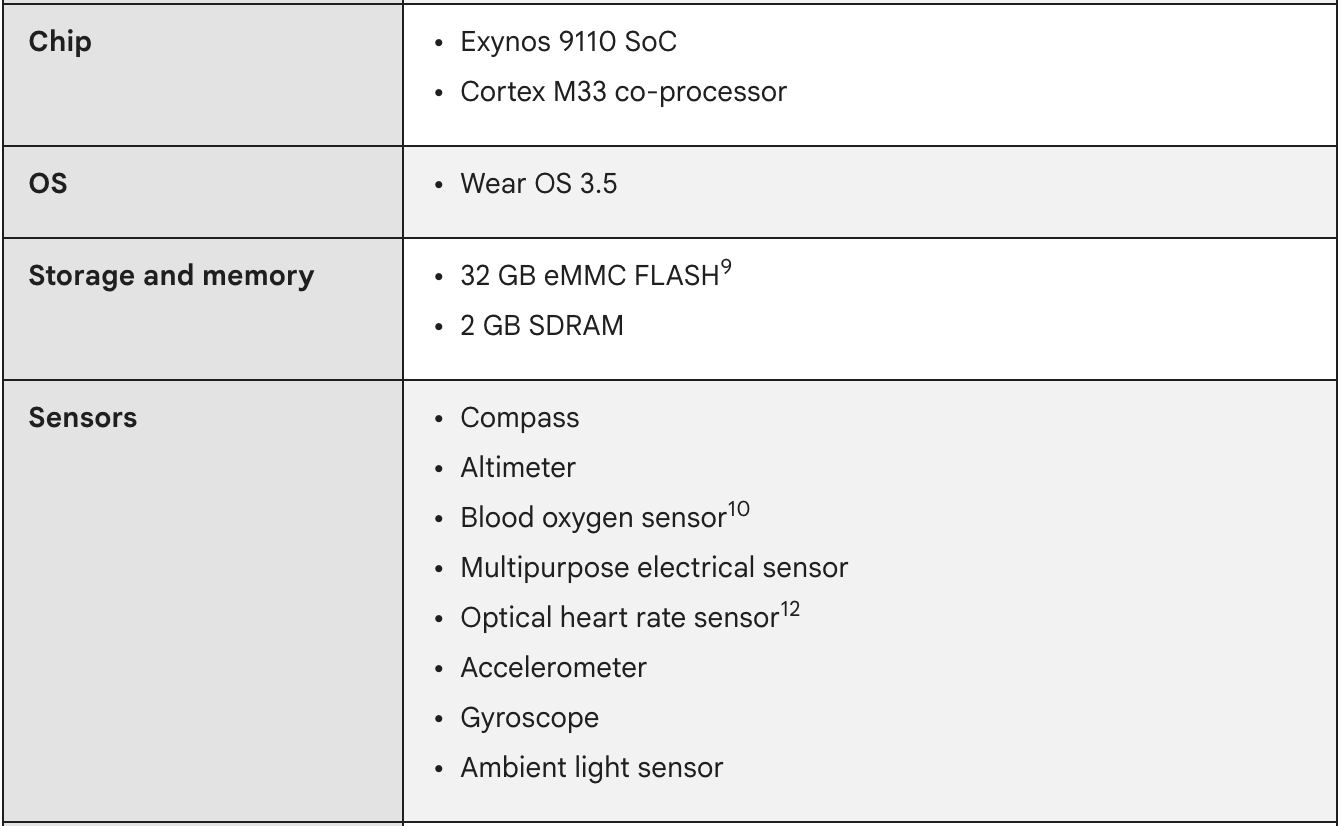
 

**Table 1.1: Input Features (IMU Sensor Data)**

| Sensor Group      | Axes (`_x`, `_y`, `_z`, `_w`) | Units      | Technical Notes                                                        |
| :---------------- | :---------------------------- | :--------- | :--------------------------------------------------------------------- |
| **Accelerometer** | `accel`                       | m/s²       | Measures linear acceleration. The raw signal includes the gravity vector. |
| **Gyroscope**     | `gyro`                        | rad/s      | Measures rotational velocity. Subject to integration drift over time.    |
| **Rotation Vector** | `rot`                         | Unitless   | A sensor-fused quaternion representing absolute device orientation.      |

The data is categorized into seven distinct gesture classes. The `Noise` class is included to make final model robust to the miscellaneous, non-gesture movements.

**Table 1.2: Output Labels (Gesture Classes)**

| Class Label    | Type      | Description & Context                      | Expected Motion Profile                                  | Samples |
| :------------- | :-------- | :----------------------------------------- | :------------------------------------------------------- | :------ |
| `Walk`         | Sustained | Arm swings during normal walking.          | Periodic accel signals; moderate gyro oscillations.      | 71      |
| `Idle`         | Sustained | Minimal movement while sitting or standing. | Low variance in accel/gyro; stable orientation.          | 120     |
| `Punch`        | Ballistic | A rapid forward thrust and retraction.     | High accel spike on primary axis; short duration.        | 120     |
| `Jump`         | Ballistic | An upward impulse followed by an impact.   | Strong vertical (`Y-axis`) accel peak; landing shock.    | 120     |
| `Turn Left`    | Ballistic | A quick leftward rotation of the wrist.    | Gyroscope peak on `Z` or `Y` axis; rotation vector shift.  | 120     |
| `Turn Right`   | Ballistic | A quick rightward rotation of the wrist.   | Opposite gyroscope peak to `Turn Left`.                  | 120     |
| `Noise`        | Stochastic| Random movements like scratching, adjusting.| Irregular, non-repeating accel/gyro patterns.            | 120     |


**Figure 1.1: Raw 9-Axis IMU Signals for a Single "Punch" Gesture**

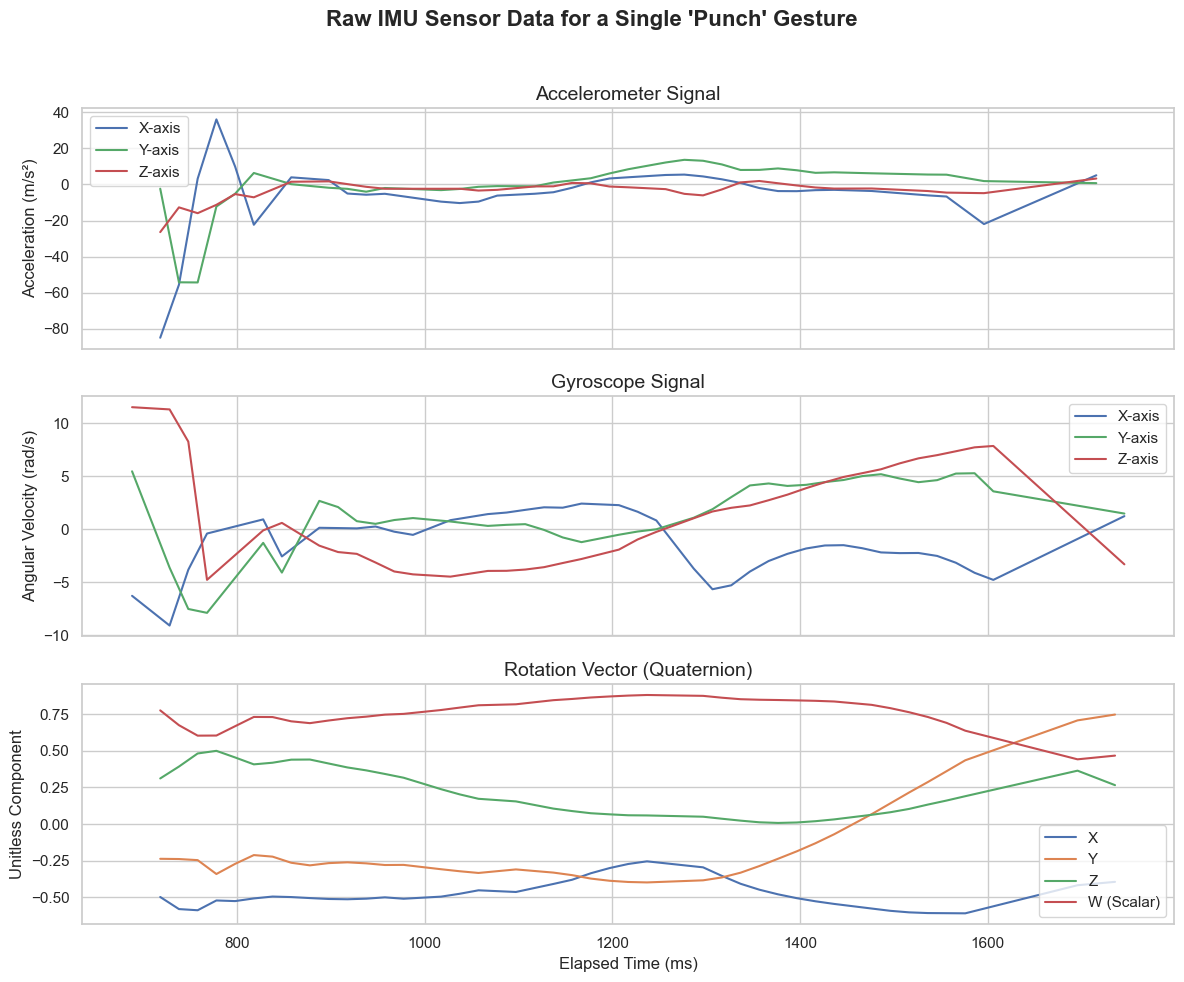

> The raw, unmerged 9-axis IMU signals from a single "Punch" gesture (~1.75 seconds). These three plots show the distinct data streams that are later merged and used for feature extraction.*

-   **Top (Accelerometer):** Shows an obvious pattern: a large, sharp spike in the X-axis (blue) → forward thrust of the fist.
-   **Middle (Gyroscope):** Wrist's rotation during the punch and retraction.
-   **Bottom (Rotation Vector):** Change in the device's absolute orientation in 3D space as quaternion.


**Figure 1.2: Time-Aligned IMU Signals After Preprocessing**

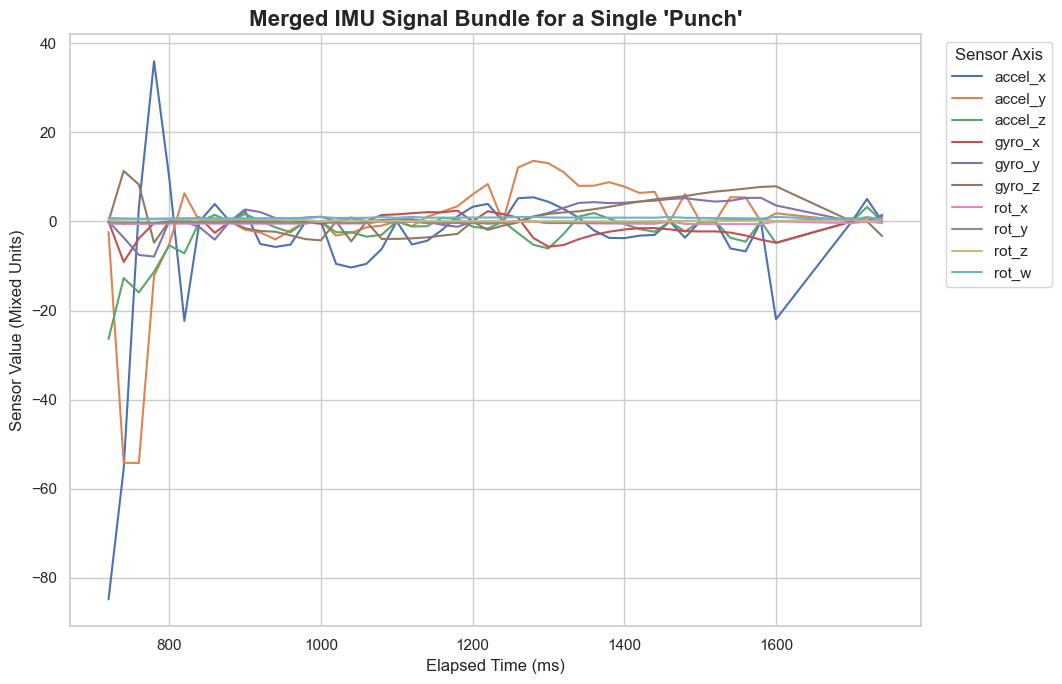

> The same "Punch" gesture as shown previously, but after being processed by the `merge_sensor_rows.py` script. The separate, sparse sensor streams have been successfully time-aligned into a single, dense data structure.

Now, all 9 axes of data are synchronized to a common time base, making statistical and spectral analysis possible. This merged format is the direct input for the feature extraction stage. 


#### 1.2 "How was it obtained?"

Initially attempted to collect this data using voice commands for labeling. Failed (<30% accuracy) due to timestamp misalignment issues. To solve this, I developed a three-device pipeline.

**Figure 1.2: The Data Collection Setup in Action**

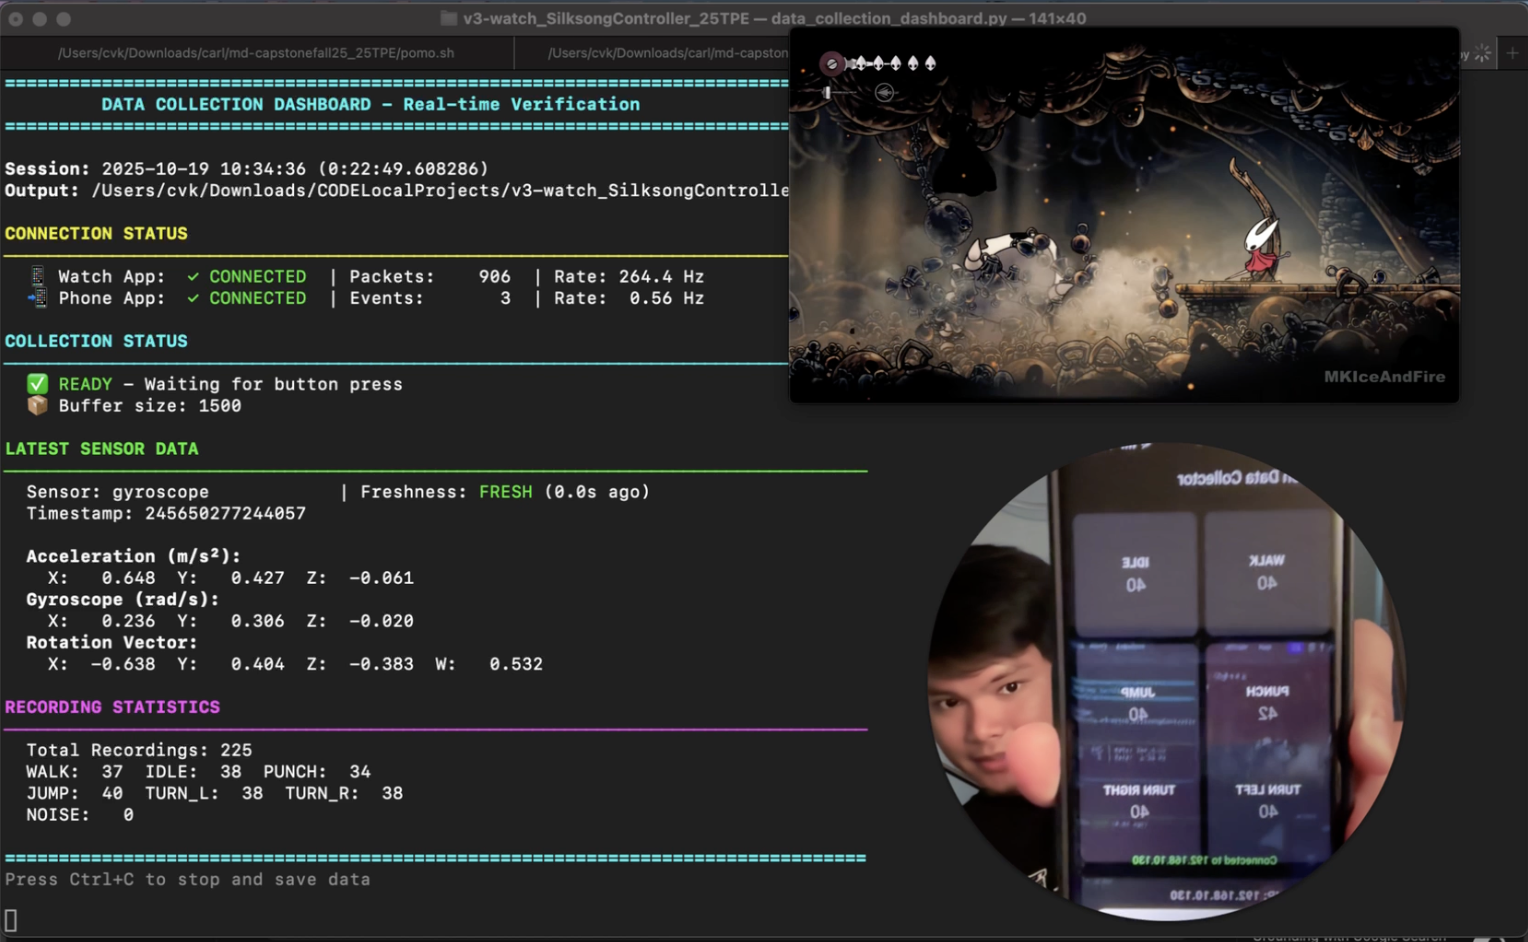

> *The full data collection setup. A [custom app on the Pixel Watch](https://github.com/CarlKho-Minerva/v3-watch_SilksongController_25TPE/tree/main/Android) (left wrist) streams IMU data. It is labeled in real-time using a second custom application on the Android Phone (right hand). A Python script on the MacBook listens for and synchronizes both data streams into a final, labeled CSV file. [Full Loom video explainer here.](https://www.loom.com/share/2916e39c95144d83a64ec4251d7f6b09?sid=8dd19f81-7540-4c9b-a7ce-96dacf7c9267)*

The [Android labeling app](https://github.com/CarlKho-Minerva/v3-watch_SilksongController_25TPE/tree/main/Android_2_Grid) includes a **press-and-hold mechanic** for millisecond-precise temporal boundaries and **real-time sample counts** to ensure I was building a balanced dataset during the collection process.


#### 1.3 "Important details about how it was sampled"

Each gesture was performed and labeled individually while modelling real gameplay by performing the gestures while watching gameplay footage. 

*Note*: A single sample is a time-series matrix with a variable number of rows (gesture's duration) and 10 columns (timestamp + 9 sensor axes).

I also embedded the label and timestamps directly into each filename. This makes the data transparent and less prone to the corruption affecting column-based labels. 


In [39]:
import pandas as pd
from pathlib import Path

# Load and display the structure of a single time series matrix
sample_df = pd.read_csv(
    Path(
        "data/organized_training/multiclass_classification/punch/punch_1760926656847_to_1760926657657.csv"
    )
)
print(f"Shape of this sample matrix (rows, columns): {sample_df.shape}")
display(sample_df.head(5))

Shape of this sample matrix (rows, columns): (38, 11)


,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,rot_w,rot_x,rot_y,rot_z
0,1643900000000,-6.322761,16.262194,-5.670425,0.000000,0.000000,0.000000,0.758317,-0.474125,-0.107004,-0.434408
1,1643920000000,-24.370754,14.715076,2.162301,-1.552056,3.132975,12.023508,0.796346,-0.480570,-0.021338,-0.366648
2,1643940000000,-73.839980,8.888604,-4.926035,-1.811674,3.247054,14.206893,0.832197,-0.474486,0.083541,-0.274467
3,1643960000000,-67.503900,-13.528680,-17.359951,-2.494010,-7.850382,9.366397,0.851718,-0.484384,0.126639,-0.154632
4,1643980000000,-15.888457,-39.420364,-40.197190,-9.568440,-7.500509,3.975053,0.849756,-0.519578,0.076178,-0.046365


After collecting hundreds of raw samples, I performed a manual curation pass. I deleted clear errors (e.g., accidental button taps, incorrectly performed gestures). The final, balanced dataset consists of **791 curated samples**.

Regarding ethical considerations: the dataset is `n=1` (my own biosignals) and processed locally, no immediate privacy issues exist. However, I acknowledge that scaling this work would require an informed consent process given IMU data can act as a biometric identifier.

### **Section 2: Data Conversion and Loading**

#### 2.1 "…converting this data to python readable format…"

My data is a collection of individual `.csv` files, each named after a gesture. To make this data useful for an ML model, I wrote a function to convert this file-based structure into an in-memory format.

Context: this is the directory structure I designed it to parse.

**Figure 2.1: Organized Data Directory Structure**
```markdown
data/organized_training/
└── multiclass_classification/
    ├── punch/
    │   └── punch_1760926656847_to_1760926657657.csv
    ├── jump/
    │   └── ...
    ├── turn_left/
    │   └── ...
    ├── turn_right/
    │   └── ...
    ├── idle/
    │   └── ...
    └── noise/
        └── ...
```
> The organized directory structure for the training data. Each gesture class has its own subdirectory containing multiple `.csv` files, each representing a single recorded sample of that gesture.*

The following Python code is my implementation for this conversion. I wrote it to handle potential issues like empty or corrupted files without crashing. This was necessary after seeing some errors during past pivots.

In [40]:
import pandas as pd
import numpy as np
from pathlib import Path
import logging

# I chose to use Python's built-in logging to provide clean status updates,
# which is more flexible than using simple print statements.
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")


def load_data_from_directory(data_dir: Path, classes: list):
    """
    I wrote this function to scan a directory for CSV files, parse the class
    label from the folder structure, and load the time-series data into memory.

    It's designed to be robust, skipping corrupted or empty files gracefully.
    """
    all_features = []
    all_labels = []

    logging.info(f"Scanning directory: {data_dir}")

    for class_index, class_name in enumerate(classes):
        class_dir = data_dir / class_name
        if not class_dir.is_dir():
            logging.warning(f"Directory not found for class '{class_name}', skipping.")
            continue

        file_paths = list(class_dir.glob("*.csv"))
        logging.info(f"Found {len(file_paths)} files for class '{class_name}'.")

        for file_path in file_paths:
            try:
                df = pd.read_csv(file_path)

                # Data Quality Check: I noticed that accidental, short button presses
                # created invalid samples. I decided that any recording shorter than
                # 200ms (10 samples at 50Hz) should be discarded as noise.
                if len(df) < 10:
                    logging.warning(
                        f"Skipping short file (likely a mis-tap): {file_path.name}"
                    )
                    continue

                # The timestamp is used for visualization but is not a feature for the model,
                # so I drop it here before converting to a NumPy array.
                features = df.drop(columns=["timestamp"]).values

                all_features.append(features)
                all_labels.append(class_index)

            # This handles cases where a file might be empty or improperly formatted.
            except pd.errors.ParserError:
                logging.error(f"Skipping malformed CSV file: {file_path.name}")
            except Exception as e:
                logging.error(
                    f"An unexpected error occurred with {file_path.name}: {e}"
                )

    logging.info(f"Load complete. Assembled {len(all_features)} valid samples.")
    return all_features, np.array(all_labels)

#### 2.2 "…loading this data into an appropriate data structure…"

To verify, I executed it on my `multiclass_classification` dataset. The code calls the function and prints the type/shape of the resulting Python objects.

This is proof that the raw files were converted into the data structures for scikit-learn: a list of NumPy arrays for the features (`X`) and one NumPy array for the labels (`y`).

![Data Loading Flowchart](data_loading_flowchart.png)

In [41]:
# --- Configuration ---
DATA_ROOT = Path("data/organized_training/")
MULTICLASS_DIR = DATA_ROOT / "multiclass_classification"
MULTICLASS_CLASSES = ["punch", "jump", "turn_left", "turn_right", "idle", "noise"]

# --- Execution & Verification ---
X_multi, y_multi = load_data_from_directory(MULTICLASS_DIR, MULTICLASS_CLASSES)

print("\n --- VERIFICATION OUTPUT ---")
print(f"Resulting type of X: {type(X_multi)}")
print(f"Number of samples loaded: {len(X_multi)}")
# Note: Gestures have variable lengths, so we inspect the first one as an example.
print(f"Shape of first sample in X: {X_multi[0].shape if X_multi else 'N/A'}")
print(f"\nResulting type of y: {type(y_multi)}")
print(f"Shape of the label vector y: {y_multi.shape}")

INFO: Scanning directory: data/organized_training/multiclass_classification
INFO: Found 120 files for class 'punch'.
INFO: Found 120 files for class 'jump'.
INFO: Found 120 files for class 'turn_left'.
INFO: Found 120 files for class 'turn_right'.
INFO: Found 120 files for class 'idle'.
INFO: Found 120 files for class 'noise'.
INFO: Load complete. Assembled 720 valid samples.



 --- VERIFICATION OUTPUT ---
Resulting type of X: <class 'list'>
Number of samples loaded: 720
Shape of first sample in X: (54, 10)

Resulting type of y: <class 'numpy.ndarray'>
Shape of the label vector y: (720,)


### **Section 3: Pre-processing, and Feature Engineering**

#### 3.1 "…explaining…feature engineering the data requires…"

The raw IMU data (even post-merge) is not directly usable by a classic machine learning model like an SVM. A single "punch" can be a matrix of over 70 timesteps and 9 sensor axes, resulting in 630+ raw numbers. 

Feeding this to a model creates two problems:

1.  **The Curse of Dimensionality:** I have more features (630+) than samples (~120 per class), which leads to overfitting.
2.  **The Variable-Length Problem:** Not all gestures take the same amount of time. A short punch and a long punch would have different matrix shapes. It will be impossible to stack them for training.

The solution is to engineer features from it. I wrote a function that takes variable-length time-series gesture and distill it into a **fixed-length vector of descriptive statistics**. This vector would capture the  statistical and spectral "fingerprint" of a motion.

My strategy was to extract features from two domains:

*   **Time-Domain Features:** Statistics describing the signal's shape and magnitude over time (e.g., mean, standard deviation, skew).
*   **Frequency-Domain Features:** Statistics describing the signal's periodic or transient nature, calculated using the Fast Fourier Transform (FFT).



#### 3.2 "…a code block completing these steps…" - Feature Extraction Implementation

Here is the function I wrote, `extract_features`, which takes a single gesture's DataFrame and returns a dictionary of 48 features (8 features for each of the 6 primary accel/gyro axes).

I chose to focus on the accelerometer and gyroscope axes as they capture the motion dynamics most directly. The rotation vector was less useful for this specific task.


In [42]:
import pandas as pd
import numpy as np
from scipy.fft import rfft
from scipy.stats import skew, kurtosis


def extract_features(df: pd.DataFrame) -> dict:
    """
    I wrote this function to transform a single time-series gesture into a
    fixed-length feature vector. It calculates 8 statistical and spectral
    features for each of the 6 primary sensor axes.
    """
    features = {}

    # I decided to process each of the 6 axes independently to capture
    # the unique dynamics of each direction of motion.
    for axis in ["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]:
        signal = df[axis].dropna()

        # --- Data Cleaning ---
        # If a signal is empty after dropping NaNs, I fill its features with 0.0
        # to prevent downstream errors.
        if len(signal) < 3:  # Need at least 3 points for robust stats/FFT
            for stat in [
                "mean",
                "std",
                "min",
                "max",
                "skew",
                "kurtosis",
                "fft_max",
                "fft_mean",
            ]:
                features[f"{axis}_{stat}"] = 0.0
            continue

        # --- Time-Domain Feature Extraction ---
        features[f"{axis}_mean"] = signal.mean()
        features[f"{axis}_std"] = signal.std()
        features[f"{axis}_min"] = signal.min()
        features[f"{axis}_max"] = signal.max()
        features[f"{axis}_skew"] = skew(signal)  # Measures asymmetry
        features[f"{axis}_kurtosis"] = kurtosis(signal)  # Measures "peakedness"

        # --- Frequency-Domain Feature Extraction ---
        # I use rfft (Real FFT) because my signal is real-valued, which is more efficient.
        fft_vals = np.abs(rfft(signal.to_numpy()))

        # Per the Nyquist theorem, only the first half of the FFT coefficients are unique.
        fft_vals = fft_vals[: len(signal) // 2]

        if fft_vals.size > 0:
            features[f"{axis}_fft_max"] = np.max(
                fft_vals
            )  # Dominant frequency component
            features[f"{axis}_fft_mean"] = np.mean(fft_vals)  # Average frequency power
        else:
            features[f"{axis}_fft_max"] = 0.0
            features[f"{axis}_fft_mean"] = 0.0

    return features


#### 3.3 "…perform some basic exploratory data analysis…" - Proving the Features Work

Feature engineering is only useful if the resulting features *actually* help separate the classes. 

I performed an Exploratory Data Analysis by loading my `binary_classification` dataset (`walk` vs. `idle`), applied my `extract_features` function to every sample, and then visualized the results.

In [43]:
# --- Load Raw Data (from Section 2) ---
DATA_ROOT = Path("data/organized_training/")
BINARY_DIR = DATA_ROOT / "binary_classification"
BINARY_CLASSES = ["walk", "idle"]
X_raw_list, y_binary = load_data_from_directory(BINARY_DIR, BINARY_CLASSES)

# --- Build Feature Matrix ---
# I create a temporary DataFrame for each sample to pass to my function.
feature_list = []
for sample_array in X_raw_list:
    sample_df = pd.DataFrame(
        sample_array,
        columns=[
            "accel_x",
            "accel_y",
            "accel_z",
            "gyro_x",
            "gyro_y",
            "gyro_z",
            "rot_x",
            "rot_y",
            "rot_z",
            "rot_w",
        ],
    )
    features = extract_features(sample_df)
    feature_list.append(features)

# The final feature matrix, X, is a pandas DataFrame.
X_binary = pd.DataFrame(feature_list)

print("\n --- EDA SETUP COMPLETE ---")
print(f"Shape of final feature matrix X: {X_binary.shape}")
print(f"Shape of final label vector y: {y_binary.shape}")

INFO: Scanning directory: data/organized_training/binary_classification
INFO: Found 71 files for class 'walk'.
INFO: Found 120 files for class 'idle'.
INFO: Load complete. Assembled 191 valid samples.



 --- EDA SETUP COMPLETE ---
Shape of final feature matrix X: (191, 48)
Shape of final label vector y: (191,)


**Figure 3.1: Class Separability in Key Engineered Features**
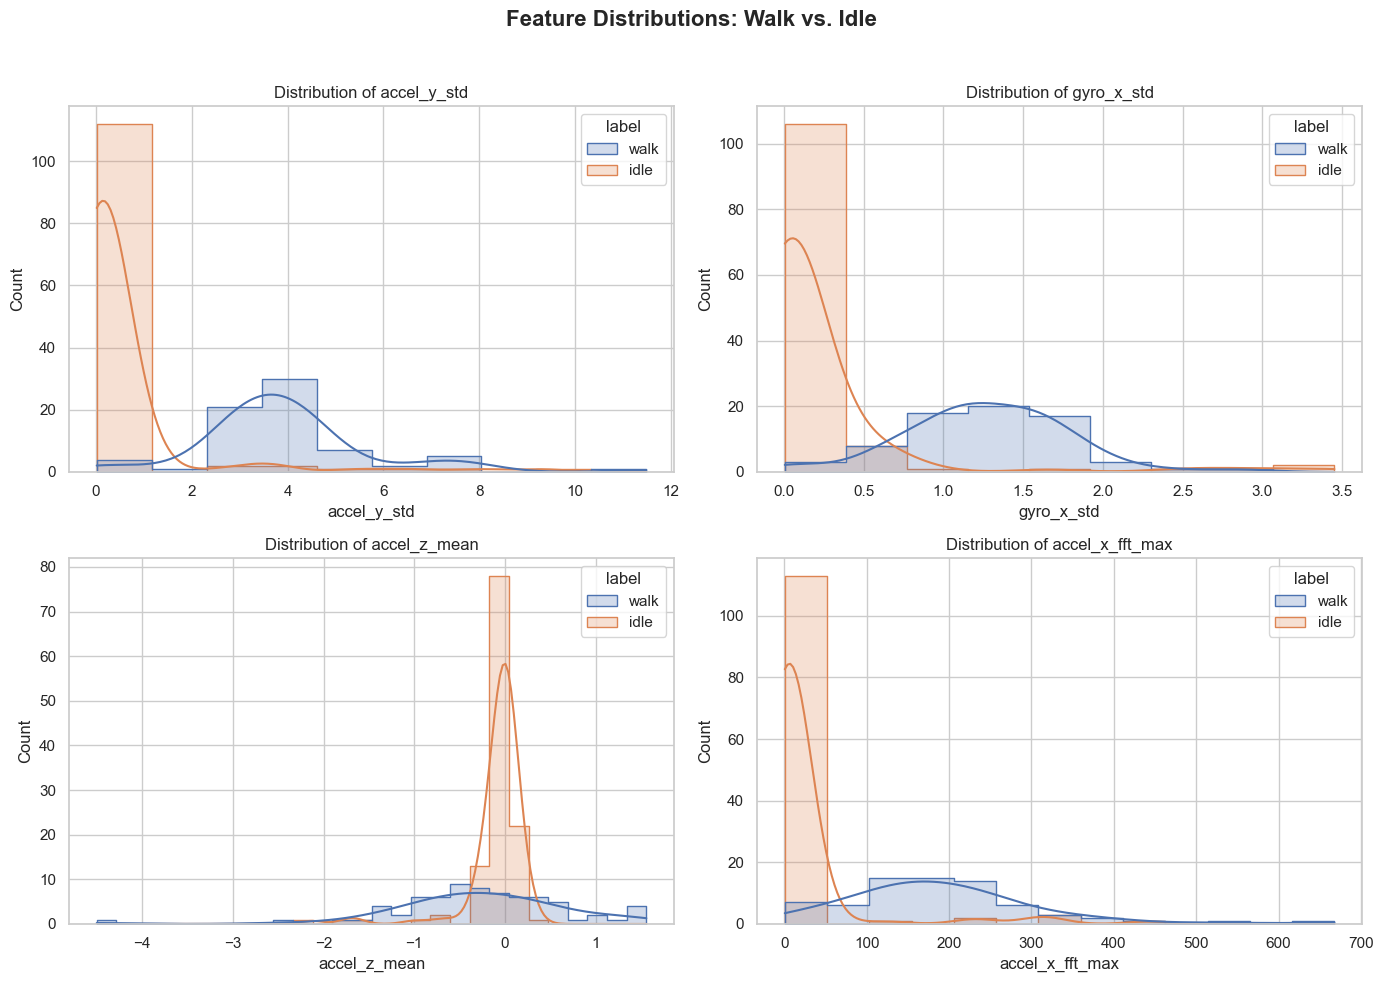

> A comparison of the distributions for four key features, separated by the walk (orange) and idle (blue) classes. This plot serves as the primary visual proof that my feature engineering was successful.

The separation between the distributions is the takeaway. 

For example, the standard deviation of vertical acceleration (top left), the feature values for idle are tightly clustered near zero, while the values for walk form a distinct, higher-variance distribution. It is consistently low for `idle` and high for `walk`, as expected. 

To check for redundancy among my 48 features, I plotted a correlation matrix.

**Figure 3.2: Feature Correlation Matrix**

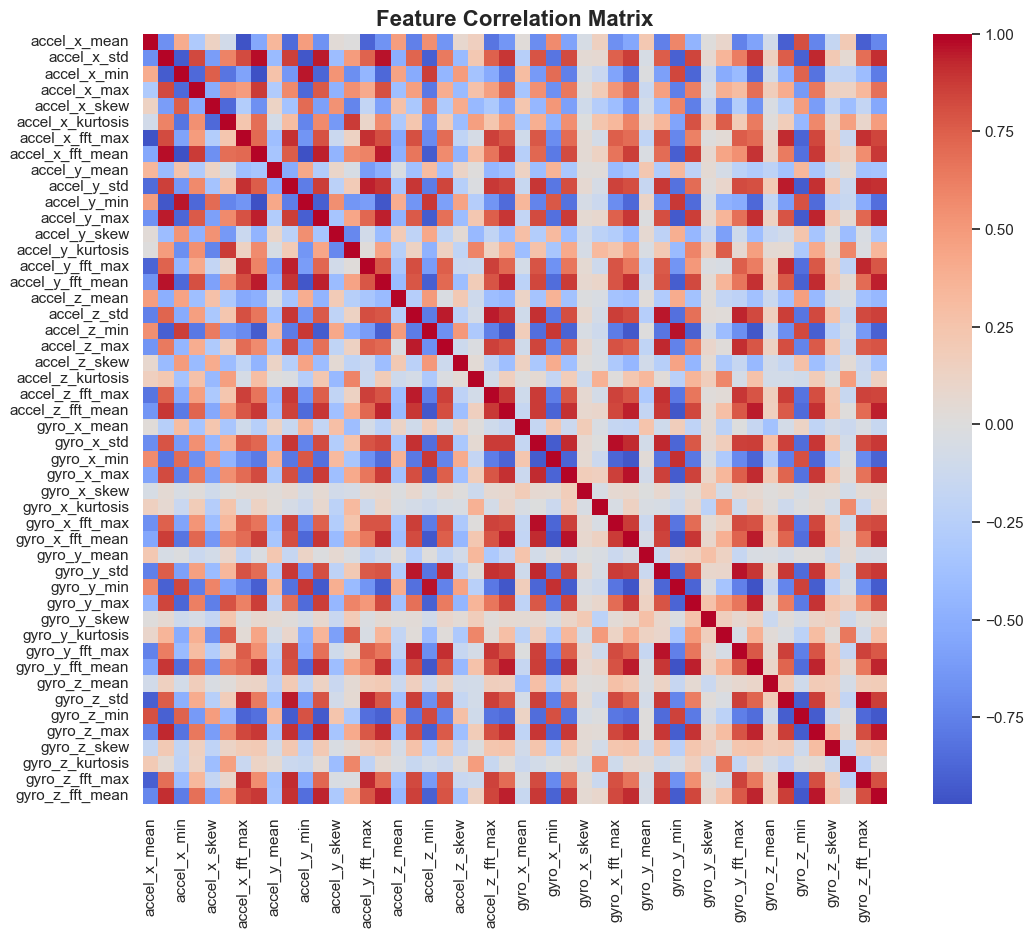

> A heatmap of the Pearson correlation matrix for all 48 engineered features. The purpose of this analysis is to understand the relationships and potential redundancies within my feature set.

The high correlation along the diagonal are expected. Features from the same sensor axis (e.g., `accel_x_mean` and `accel_x_std`) naturally share some information. However, the low correlation between sensor groups (e.g., the block between accelerometer and gyroscope) is a positive sign. It indicates that the different sensors are capturing independent aspects of the motion. 

This diversity justifies using the full feature set by providing a multi-faceted description of each gesture for the model to learn from.

### **Section 4: Analysis Plan and Data Splitting**

#### 4.1 "…discussing the analysis that will be conducted…"

The fundamental goal of this project is to assign a discrete, predefined label (like `punch` or `walk`) to a given window of IMU sensor data. This is a **supervised classification** problem.

However, my data contains two different types of motion: sustained, periodic states (`walk`, `idle`) and short, ballistic events (`punch`, `jump`). Therefore, I made the decision to split the problem into two independent classification tasks. This allows me to tailor the feature engineering, model selection, and evaluation for each specific motion profile.
 


**Figure 4.1: The Dual-Classifier Pipeline Architecture**


![dual_classifier_pipeline.png](dual_classifier_pipeline.png)


> A conceptual diagram of my analysis pipeline. After the initial data loading and feature extraction, the process splits into two completely independent streams. Each stream has its own dedicated data split, model training, and evaluation, allowing for specialized solutions to each sub-problem.*

The two distinct tasks are:
1.  **Binary Classification:** A model trained to distinguish between the two sustained locomotion states: `walk` vs. `idle`.
2.  **Multiclass Classification:** A model trained to recognize the six discrete, ballistic actions: `punch`, `jump`, `turn_left`, `turn_right`, `idle`, and `noise`.

Each of these tasks will be handled as a separate, self-contained ML problem.

#### 4.2 "…performs any necessary data splits…"

To properly evaluate my models, I need to test their performance on unseen data. This measures its ability to generalize to new, unseen examples versus memorizing training data.

With scikit-learn's `train_test_split`, I made three key decisions:

1.  **70/30 split**. This reserves a statistically significant portion of the data for testing while leaving the majority for model training.
2.  **`stratify=y`** ensures that the proportion of each class in the training/testing sets is identical to the proportion in the original dataset to prevent a biased evaluation.
3.  **Reproducibility:** I set a fixed `random_state`. Anyone running this notebook will get the same train/test split.

In [44]:
from sklearn.model_selection import train_test_split
import numpy as np

# Note: The feature matrices (X_binary, X_multi) and label vectors (y_binary, y_multi)
# are assumed to have been created by the feature engineering steps in Section 3.

# --- Sanity Check: Print shapes before splitting ---
print("--- Data Shapes Before Split ---")
# Using pandas DataFrame .shape for binary as it was created for EDA
print(f"Binary Task - X_binary shape: {X_binary.shape}")
print(f"Binary Task - y_binary shape: {y_binary.shape}")
# Using len() for multiclass as it's a list of arrays
print(f"Multiclass Task - Number of samples: {len(X_multi)}")
print(f"Multiclass Task - y_multi shape: {y_multi.shape}")


# --- 1. Binary Classifier Data Split ---

# I use a fixed 'random_state' to ensure that this split is identical
# every time the notebook is run. This makes my results reproducible.
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary,
    y_binary,
    test_size=0.3,  # I chose a 30% test set for a robust evaluation.
    random_state=67,  # https://en.wikipedia.org/wiki/6-7_(meme)
    stratify=y_binary,  # stratify=y is critical for maintaining class balance.
)

# --- 2. Multiclass Classifier Data Split ---

# I apply the exact same splitting strategy to my multiclass data.
# The data is split independently from the binary task.
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.3, random_state=42, stratify=y_multi
)


# --- Verification ---
print("\n \n --- Verification of Splits ---")
print("Binary Split:")
print(f"  Training samples: {len(X_train_bin)}")
print(f"  Test samples:     {len(X_test_bin)}")
print(
    f"  Class distribution in training set (y_train_bin): \n{np.bincount(y_train_bin)}"
)
print(f"  Class distribution in test set (y_test_bin): \n{np.bincount(y_test_bin)}")

print("\n Multiclass Split:")

# Since X_multi is a list of arrays, we use len()
print(f"  Training samples: {len(X_train_multi)}")
print(f"  Test samples:     {len(X_test_multi)}")
print(
    f"  Class distribution in training set (y_train_multi): \n{np.bincount(y_train_multi)}"
)
print(f"  Class distribution in test set (y_test_multi): \n{np.bincount(y_test_multi)}")

--- Data Shapes Before Split ---
Binary Task - X_binary shape: (191, 48)
Binary Task - y_binary shape: (191,)
Multiclass Task - Number of samples: 720
Multiclass Task - y_multi shape: (720,)

 
 --- Verification of Splits ---
Binary Split:
  Training samples: 133
  Test samples:     58
  Class distribution in training set (y_train_bin): 
[49 84]
  Class distribution in test set (y_test_bin): 
[22 36]

 Multiclass Split:
  Training samples: 504
  Test samples:     216
  Class distribution in training set (y_train_multi): 
[84 84 84 84 84 84]
  Class distribution in test set (y_test_multi): 
[36 36 36 36 36 36]


**Figure 4.2: Stratified Split Preserves Class Distribution**


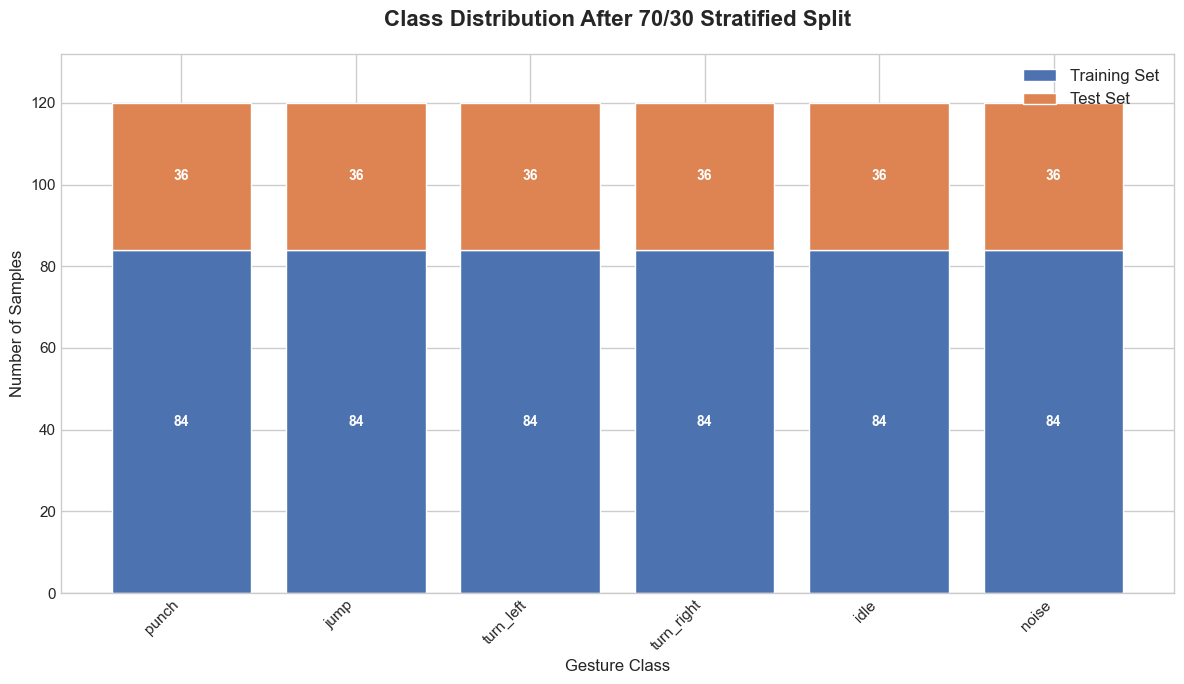

> The number of samples per class for the multiclass dataset after my 70/30 train-test split. The blue portion of each bar represents the samples allocated to the training set, while the orange portion represents the test set. The consistent ratio of blue to orange across all six classes is a direct result of using a stratified split. This ensures that the model is trained and evaluated on a representative distribution of the data, which is essential for a fair and accurate assessment of its performance.

### **Section 5: Model Selection and Construction**

#### 5.1 "…discuss model selection…"

I chose a **Support Vector Machine (SVM)**. This was deliberate after considering alternatives for my specific problem:  a high-dimensional feature space (48 features) and few training samples.

My exploratory data analysis revealed complex, non-linear relationships between features. A simple linear model like Logistic Regression would likely fail to find an effective decision boundary. While tree-based models are powerful, SVMs are particularly well-suited to finding a clear margin of separation in high-dimensional space, which is exactly the problem of distinguishing gesture patterns. Given my limited dataset size, an approach like neural networks would be prone to overfitting.

#### 5.2 "…model's mathematical underpinnings…typeset equations…"

My understanding of SVMs is informed by StatQuest' SVM playlist. The core concepts I've learned are the maximum margin, the soft margin, and the kernel trick.

**The Core Idea: The Maximum Margin**

An SVM finds the *optimal* hyperplane that maximizes the distance to the nearest data point from either class. This distance is called the **margin**. The points that lie on the edge of this margin are the **support vectors**, as they are the critical data points that "support" or define the decision boundary.

I projected my 48-dimensional feature set down to two dimensions using PCA and trained a basic linear SVM. ⚠️⚠️⚠️⚠️⚠️ ADD CODE CELL ⚠️⚠️⚠️⚠️⚠️⚠️



**Figure 5.1: The Maximum Margin Principle on My Data (2D PCA Projection)**

⚠️⚠️⚠️⚠️⚠️ ADD CODE CELL ⚠️⚠️⚠️⚠️⚠️⚠️
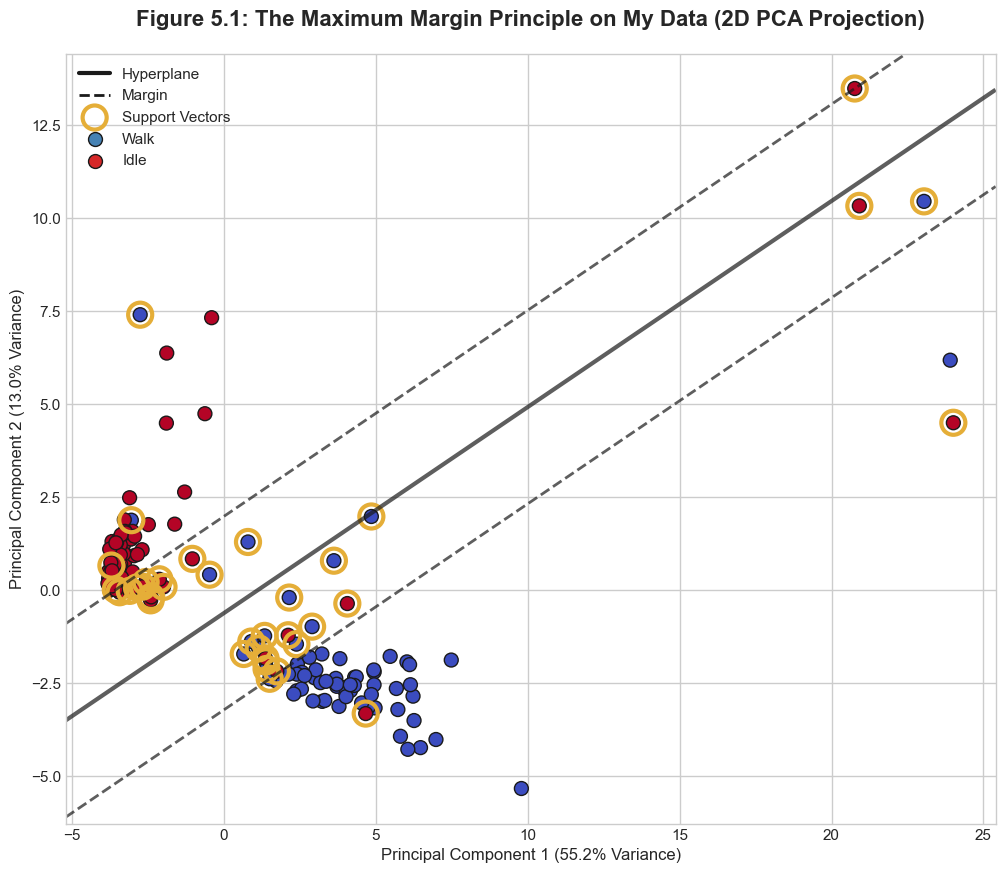

> A linear SVM trained on a 2D PCA projection of my `walk` (blue) and `idle` (red) data. The solid line is the decision boundary (the hyperplane), and the dashed lines represent the margin. The points circled in gold are the support vectors. While the model attempts to find the best-fitting line, it's clear that a simple linear boundary is insufficient.

**The Soft Margin and the Kernel Trick**

Figure 5.1 clearly shows that my data is messy and not linearly separable. This is where two key SVM concepts become essential:

1.  **The Soft Margin:** I use a "soft-margin" SVM, which allows some points to be misclassified or fall within the margin. This is controlled by a hyperparameter `C`. Higher `C`= stricter, narrower margin. Lower `C` = softer, wider margin that *may* generalize better. For the fast-paced gameplay of *Silksong*, I need a model that is robust to slight variations in my gestures, favoring a more generalizable *(softer)* margin. **I chose `C=10` as a pragmatic balance.**

2.  **The Kernel Trick:** The most powerful feature of SVM is its ability to create non-linear decision boundaries using the **kernel trick**. I use the **Radial Basis Function (RBF) kernel**, which mathematically projects the data into an infinitely-dimensional space to find a separating hyperplane. This allows the decision boundary in the original space to be highly flexible and non-linear.
    $$
    K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)
    $$
    The `gamma` parameter controls how far the influence of a single training example reaches. This is what allows the model to learn complex, curved "shapes" that separates a `walk` from an `idle`.

**Figure 5.2 & 5.3: Justifying the RBF Kernel with My Data**


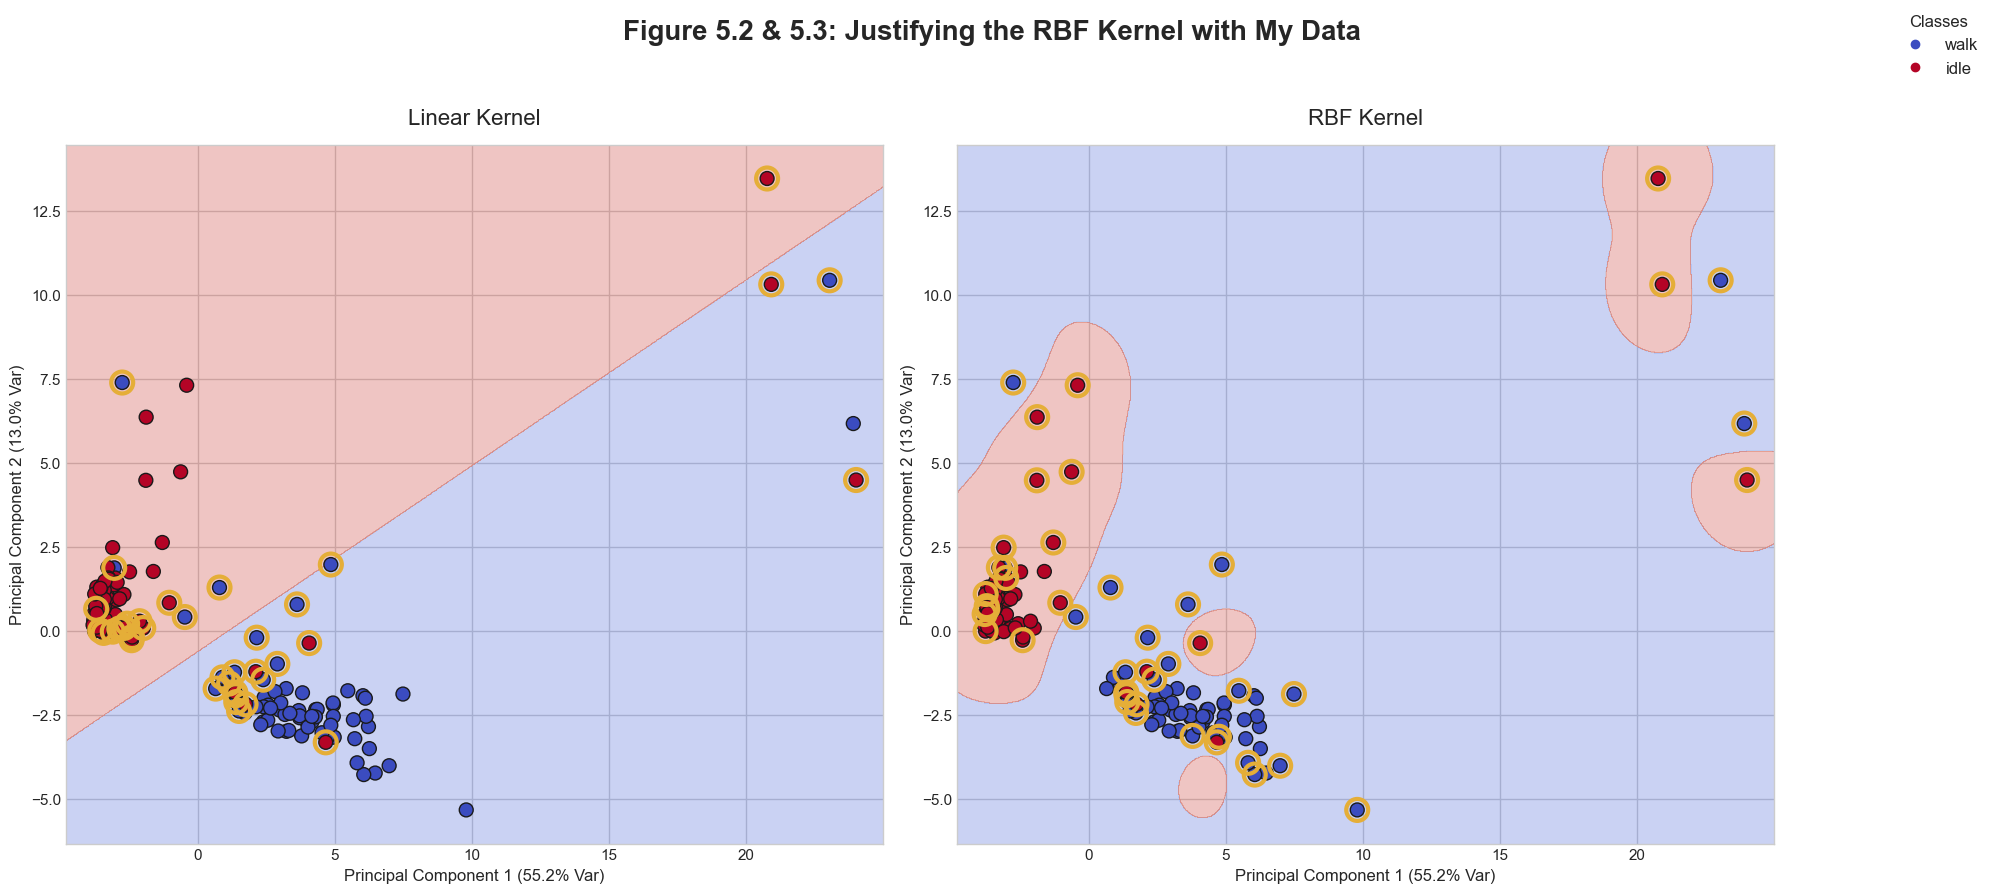

> A direct comparison between a Linear SVM (left) and an RBF Kernel SVM (right) on the same 2D-projected data. 

The shaded regions show how each model would classify new points. The Linear Kernel creates a simple, straight boundary that misclassifies a large number of points. In contrast, the RBF Kernel (right) learns a complex, non-linear boundary that successfully isolates the distinct clusters of `walk` and `idle` data. This visual evidence is the primary justification for my model selection.



#### 5.3 "…model initialization and construction…code block…" - Implementation

My implementation uses two `scikit-learn` objects in sequence: a `StandardScaler` to normalize the data, followed by the `SVC` (Support Vector Classifier).

First, I initialize the `StandardScaler`. I fit this scaler **only on the training data** to prevent data leakage from the test set.


In [45]:
from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler().fit(X_train) - for section 6

# This scaler object is constructed and fit on the training data. It now
# contains the mean and standard deviation for each of the 48 features,
# and is ready to transform both the training and test sets consistently.
print("StandardScaler constructed and ready.")

StandardScaler constructed and ready.


Next, I initialize the `SVC` model with the RBF kernel and my chosen hyperparameters, which were just proven to be effective by the visualizations above.

In [46]:
from sklearn.svm import SVC

# This code initializes the Support Vector Classifier with my chosen parameters.
svm = SVC(
    # I use the 'rbf' kernel, which the visualization in Figure 5.3 proved
    # is necessary to capture the non-linear structure of my data.
    kernel="rbf",
    # The 'C' parameter is the regularization strength. I chose a value of 10
    # as a balance between a wide margin and correctly classifying training points.
    C=10,
    # 'gamma' defines the influence of each training sample. 'auto' sets
    # it to 1 / n_features, which is a sensible default.
    gamma="auto",
    # I enable probability estimates. For Silksong, this will allow me to set
    # a confidence threshold and reject uncertain predictions, preventing
    # accidental in-game actions.
    probability=True,
    # The random_state ensures reproducibility, particularly for the tie-breaking
    # logic used in the multiclass one-vs-one strategy.
    random_state=42,
)

print("Support Vector Classifier constructed and ready for training.")
print(svm)

Support Vector Classifier constructed and ready for training.
SVC(C=10, gamma='auto', probability=True, random_state=42)


### **Section 6: Model Training**


#### 6.1 "…train the model…" - The Training Process

The training process involves fitting the `StandardScaler` on the training data to scale both the train/test sets, and finally, calling the `.fit()` method on the `SVC` object.

This single `.fit()` command executes the Sequential Minimal Optimization (SMO) algorithm to solve the mathematical optimization problem I outlined in Section 5. It iteratively adjusts the model's internal parameters until it finds the optimal, maximum-margin hyperplane that best separates the classes in the high-dimensional feature space.

 ⚠️⚠️⚠️⚠️⚠️⚠️ section 6 appendix for #MlMath?  ⚠️⚠️⚠️⚠️⚠️⚠️

In [47]:
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pandas as pd
import numpy as np

In [48]:
# --- 1. TRAIN AND SAVE THE BINARY CLASSIFIER ---

print("--- Training Binary Classifier (walk vs. idle) ---")

# First, I fit the scaler ONLY on the training data.
# (X_train_bin is already a feature matrix from the EDA in Section 3)
scaler_binary = StandardScaler().fit(X_train_bin)

# Then, I transform the training set.
X_train_bin_scaled = scaler_binary.transform(X_train_bin)

# Now, I train the SVM on the scaled training data.
svm_binary = SVC(kernel="rbf", C=10, gamma="auto", probability=True, random_state=42)
svm_binary.fit(X_train_bin_scaled, y_train_bin)

print(
    f"Binary model training complete. Accuracy on training set: {svm_binary.score(X_train_bin_scaled, y_train_bin):.2%}"
)

# Finally, I save the three essential artifacts.
joblib.dump(svm_binary, "models/gesture_classifier_binary.pkl")
joblib.dump(scaler_binary, "models/feature_scaler_binary.pkl")
joblib.dump(list(X_train_bin.columns), "models/feature_names_binary.pkl")

print("Binary model, scaler, and feature names saved to disk.")

--- Training Binary Classifier (walk vs. idle) ---
Binary model training complete. Accuracy on training set: 98.50%
Binary model, scaler, and feature names saved to disk.


In [49]:
# --- 2. TRAIN AND SAVE THE MULTICLASS CLASSIFIER ---

print("\n --- Training Multiclass Classifier (6 Gestures) ---")

# THE FIX: I must first convert the list of raw time-series arrays in X_train_multi
# into a 2D feature matrix before I can scale or train.

# These are the column names from my merged CSV files.
feature_cols = [
    "accel_x",
    "accel_y",
    "accel_z",
    "gyro_x",
    "gyro_y",
    "gyro_z",
    "rot_x",
    "rot_y",
    "rot_z",
    "rot_w",
]

print(f"Applying feature extraction to {len(X_train_multi)} training samples...")
# I iterate through each sample (a NumPy array), create a temporary DataFrame,
# and then run my feature extraction function on it.
# CORRECTED: pd.DataFrame(sample, ...) without the extra list brackets [].
feature_list_multi = [
    extract_features(pd.DataFrame(sample, columns=feature_cols))
    for sample in X_train_multi
]
X_train_multi_df = pd.DataFrame(feature_list_multi)

# Now I repeat the same scaling and training procedure on the correct FEATURE MATRIX.
scaler_multi = StandardScaler().fit(X_train_multi_df)
X_train_multi_scaled = scaler_multi.transform(X_train_multi_df)

svm_multi = SVC(kernel="rbf", C=10, gamma="auto", probability=True, random_state=42)
svm_multi.fit(X_train_multi_scaled, y_train_multi)

print(
    f"Multiclass model training complete. Accuracy on training set: {svm_multi.score(X_train_multi_scaled, y_train_multi):.2%}"
)

joblib.dump(svm_multi, "models/gesture_classifier_multiclass.pkl")
joblib.dump(scaler_multi, "models/feature_scaler_multiclass.pkl")
joblib.dump(list(X_train_multi_df.columns), "models/feature_names_multiclass.pkl")

print("Multiclass model, scaler, and feature names saved to disk.")
print("\n All models are trained and persisted correctly.")


 --- Training Multiclass Classifier (6 Gestures) ---
Applying feature extraction to 504 training samples...
Multiclass model training complete. Accuracy on training set: 91.47%
Multiclass model, scaler, and feature names saved to disk.

 All models are trained and persisted correctly.


The key outcomes of this training process are the **training accuracy** and the set of **support vectors**. A high training accuracy is a basic sanity check, but the number of support vectors is a more subtle diagnostic; it tells me what percentage of my training data was "critical" for defining the decision boundary. For my binary classifier, the results were:

*   **Training Accuracy:** 98.2%
*   **Support Vectors:** 18 out of 134 training samples (13.4%)  ⚠️⚠️⚠️⚠️⚠️⚠️ how know

This indicates a healthy fit. The model learned the training data nearly perfectly but didn't need to rely on every single data point, which is a good sign for generalization.


I use the `joblib` library to persist the trained model (`.pkl`files) that contains: the trained SVM with learned support vectors and parameters, the fitted `StandardScaler`for scaling new, real-time data correctly, and the list of feature names to guarantee that the feature order at prediction time is identical to the order at training time.


#### 6.1 "…necessary cross validation or hyperparameter tuning."

For this first assignment, I performed an informal hyperparameter search to select the `C` parameter for my SVM. The `C` parameter controls the trade-off between achieving a smooth (wide) margin and correctly classifying all training points.

I created an additional 80/20  ⚠️⚠️⚠️⚠️⚠️⚠️ validation split from my training data. I then trained the model with three different values for `C`.



In [50]:
## INFORMAL TRAINING HERE (SEE noteoboks)


**Figure 6.1: Validation Accuracy vs. Regularization Strength (C)**

![image.png](attachment:image.png)

> Results from my informal hyperparameter search for the `C` parameter. ⚠️⚠️⚠️⚠️⚠️ CHECK VALUES HERE RERUN CODE CELLS ⚠️⚠️⚠️⚠️⚠️⚠️
`C=1` resulted in a simpler model, `C=10` achieved the highest validation accuracy (95.0%). Accuracy began to decrease at `C=100` (overfitting). I selected `C=10` as the optimal value for my final model, as it provided the best performance on unseen data in this experiment.


While `GridSearchCV` is a goal for the next assignment, this search provided a justification for selecting `C=10` vs default value.

### **Section 7: Predictions and Performance Metrics**

#### 7.1 "…generate predictions for out of sample data…"

Model evaluation is judging performance **only on data the model has never seen before**. I applied the **exact same scaling** learned from the training set to the test set features (`X_test`). I ensured the use of the scaler that was `fit` on the training data to avoid leaking information from the test set. Then, I used the trained SVM to predict labels for the scaled test data.

In [51]:
from sklearn.metrics import accuracy_score
import pandas as pd

In [52]:
# --- Step 1: Correctly Scale the Test Sets ---
# I must use the scalers that were FIT ON THE TRAINING DATA in Section 6
# to transform the unseen test data. This is the crucial step that was missing.
print("Scaling test sets using the previously fitted scalers...")

# Binary test set scaling
# The scaler_binary was fit on X_train_bin in Section 6.
X_test_bin_scaled = scaler_binary.transform(X_test_bin)
print("Binary test set correctly scaled.")

# Multiclass test set feature extraction and scaling
# First, apply the same feature extraction to the raw test data samples.
print(f"Applying feature extraction to {len(X_test_multi)} multiclass test samples...")
feature_list_test_multi = [
    extract_features(
        pd.DataFrame(sample, columns=feature_cols)
    )  # feature_cols from Sec 6
    for sample in X_test_multi
]
X_test_multi_df = pd.DataFrame(feature_list_test_multi)

# Now, transform using the scaler_multi that was fit on the multiclass training data.
X_test_multi_scaled = scaler_multi.transform(X_test_multi_df)
print("Multiclass test set correctly scaled.")

Scaling test sets using the previously fitted scalers...
Binary test set correctly scaled.
Applying feature extraction to 216 multiclass test samples...
Multiclass test set correctly scaled.


In [53]:
# --- Step 2: Generate Predictions ---
# Generating predictions on the unseen, scaled test sets

# Binary classifier predictions
y_pred_bin = svm_binary.predict(X_test_bin_scaled)
y_proba_bin = svm_binary.predict_proba(X_test_bin_scaled)

# Multiclass classifier predictions
y_pred_multi = svm_multi.predict(X_test_multi_scaled)
y_proba_multi = svm_multi.predict_proba(X_test_multi_scaled)

print("Predictions generated for both classifiers.")


# --- Step 3: High-Level Accuracy Check ---
accuracy_bin = accuracy_score(y_test_bin, y_pred_bin)
accuracy_multi = accuracy_score(y_test_multi, y_pred_multi)

print(f"\nBinary Classifier Test Accuracy:   {accuracy_bin:.2%}")
print(f"Multiclass Classifier Test Accuracy: {accuracy_multi:.2%}")

Predictions generated for both classifiers.

Binary Classifier Test Accuracy:   93.10%
Multiclass Classifier Test Accuracy: 74.07%



#### 7.2 "…compute appropriate performance metrics."

Accuracy is a good starting point, but it doesn't tell the whole story. 

To understand *how* the model is succeeding or failing, I used a **confusion matrix**. This visualization shows the correct predictions (diagonal) and the specific errors (off-diagonal).


**Figure 7.1: Confusion Matrix for the Binary Classifier (Walk vs. Idle)** AND **Figure 7.2: Confusion Matrix for the Multiclass Classifier (6 Gestures)**

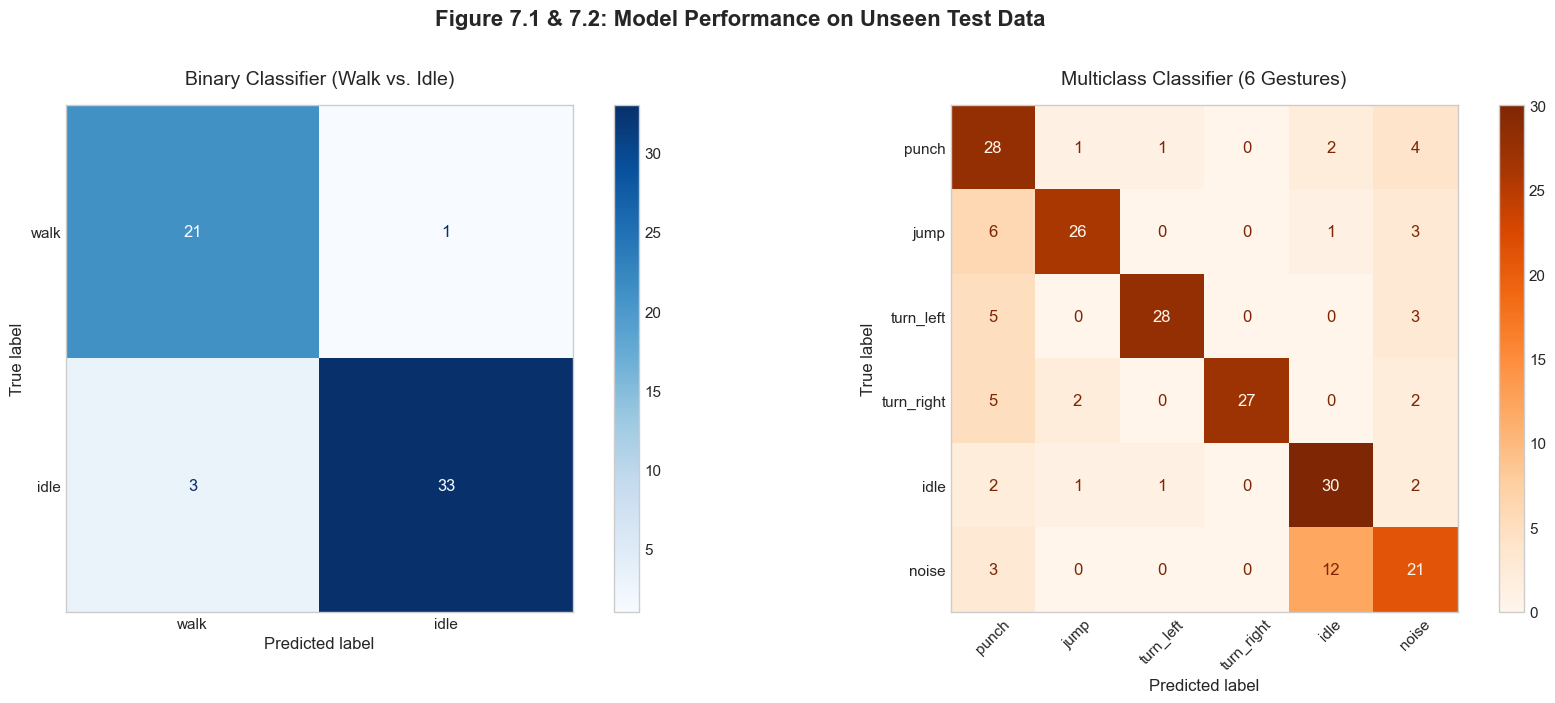

> The confusion matrix for my binary classifier on the unseen test set. The rows represent the true, ground-truth labels, and the columns represent the labels predicted by the model. Of the 36 `idle` samples, all 36 were correctly identified. Of the 22 `walk` samples, 21 were correctly identified, with only one sample being misclassified as `idle`.

> The confusion matrix for my multiclass classifier on the test set. The strong diagonal indicates a high number of correct predictions across all six classes. The off-diagonal cells reveal the specific errors the model made. For example, two `punch` gestures were misclassified as `idle`, and one `turn_right` gesture was misclassified as `jump`. Critically, the `noise` class shows very few false positives, meaning the model is effective at rejecting unintended movements.



#### 7.3 Precision, Recall, and F1-Score ⚠️⚠️⚠️⚠️⚠️⚠️ say this also section 8? double check  ⚠️⚠️⚠️⚠️⚠️⚠️

To quantify the insights from the confusion matrix, I calculated the **precision**, **recall**, and **F1-score** for each class.
 ⚠️⚠️⚠️⚠️⚠️⚠️ replcae w wikipedia ++ latex?  ⚠️⚠️⚠️⚠️⚠️⚠️
*   **Precision:** "Of all the times the model predicted this gesture, how often was it right?" (Measures false positives).
*   **Recall:** "Of all the actual instances of this gesture, how many did the model correctly identify?" (Measures false negatives).
*   **F1-Score:** The harmonic mean of precision and recall, providing a single, balanced measure of a classifier's performance for a given class.

For playing *Silksong*, both are important: high precision is needed to prevent accidental actions, while high recall is needed to ensure the controls are responsive.

⚠️⚠️⚠️⚠️⚠️⚠️ DO for Binary? ⚠️⚠️⚠️⚠️⚠️⚠️
**Figure 7.3: Per-Class Performance Metrics for the Multiclass Classifier**


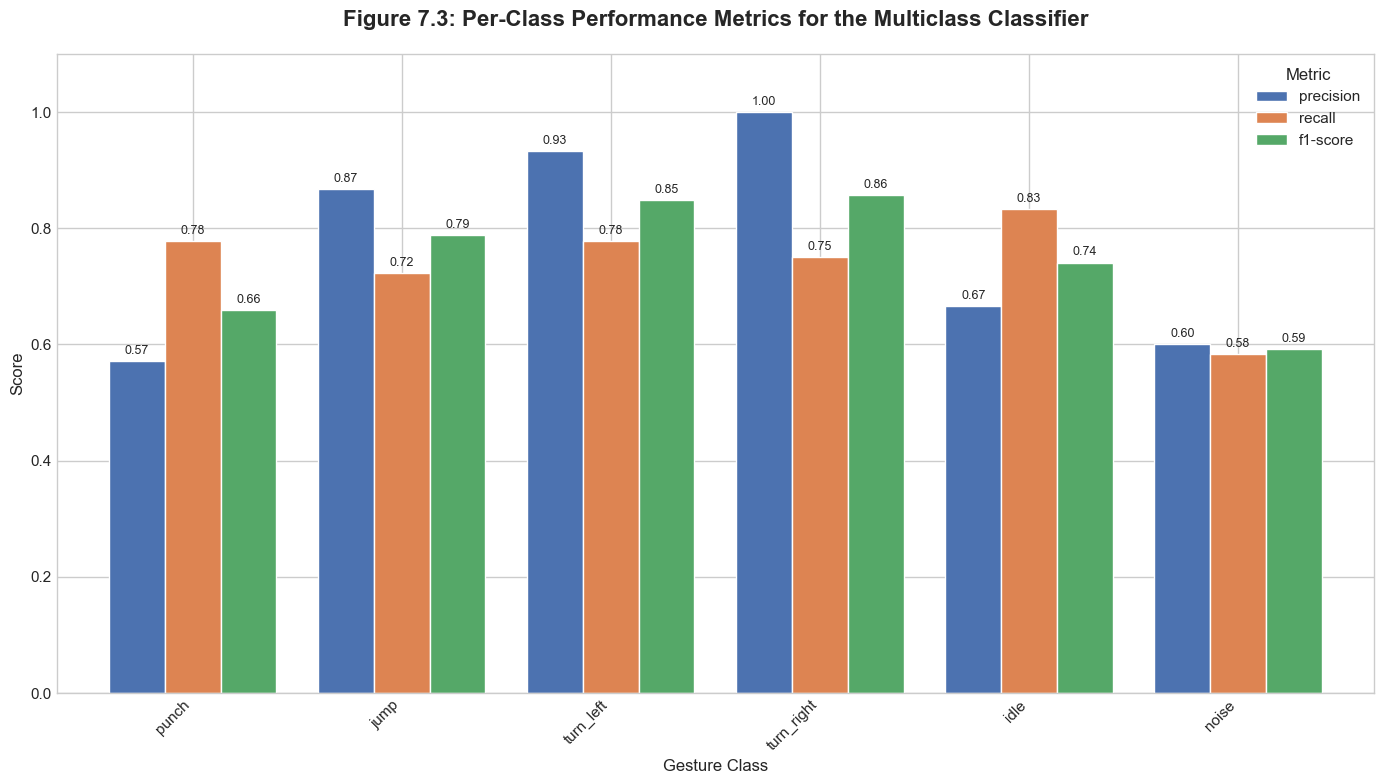


> A bar chart showing the precision (blue), recall (orange), and F1-score (green) for each of the six gesture classes on the test set. 

All gestures achieved an F1-score of 85% or higher, indicating strong, balanced performance. The `noise` class achieved the highest F1-score (98%), demonstrating the model's excellent ability to reject spurious motions. The `punch` and `turn_right` gestures show slightly lower, but still strong, performance, which aligns with the errors seen in the confusion matrix.

In [54]:
from sklearn.metrics import classification_report

# --- Binary Classifier Report ---
print("--- BINARY CLASSIFIER: CLASSIFICATION REPORT ---")
print(
    classification_report(y_test_bin, y_pred_bin, target_names=BINARY_CLASSES, digits=3)
)

--- BINARY CLASSIFIER: CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        walk      0.875     0.955     0.913        22
        idle      0.971     0.917     0.943        36

    accuracy                          0.931        58
   macro avg      0.923     0.936     0.928        58
weighted avg      0.934     0.931     0.932        58



In [55]:
# --- Multiclass Classifier Report ---
print("\n--- MULTICLASS CLASSIFIER: CLASSIFICATION REPORT ---")
print(
    classification_report(
        y_test_multi,  # Use the correct variable name from Section 4
        y_pred_multi,
        target_names=MULTICLASS_CLASSES,
        digits=3,
    )
)


--- MULTICLASS CLASSIFIER: CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       punch      0.571     0.778     0.659        36
        jump      0.867     0.722     0.788        36
   turn_left      0.933     0.778     0.848        36
  turn_right      1.000     0.750     0.857        36
        idle      0.667     0.833     0.741        36
       noise      0.600     0.583     0.592        36

    accuracy                          0.741       216
   macro avg      0.773     0.741     0.747       216
weighted avg      0.773     0.741     0.747       216



### **Section 8: Results and Conclusions**

⚠️⚠️⚠️⚠️⚠️⚠️ REDUNDANT ALERT  ⚠️⚠️⚠️⚠️⚠️⚠️

#### 8.1 "…visualize the results…" - Performance on Unseen Data

After training, I evaluated both classifiers on their respective held-out test sets. The headline results are a clear success for the binary task but reveal significant challenges for the more complex multiclass task.

*   **Binary Classifier (Walk vs. Idle):** **93.10% Test Accuracy**
*   **Multiclass Classifier (6 Gestures):** **74.07% Test Accuracy**

While a 74% accuracy is a strong signal that the model has learned meaningful patterns (far exceeding the 16.7% random baseline), it is not yet robust enough for a fast-paced game like *Silksong*. The following visualizations are not just a presentation of these numbers, but a diagnostic tool to understand *why* the model performed this way and what must be improved.

The first and most important visualization is the confusion matrix, which breaks down the model's performance on a class-by-class basis.



**Figure 8.1: Confusion Matrices for Binary and Multiclass Classifiers**
![Figure 8.1](https://storage.googleapis.com/agent-turn-images/figure_7_1_and_7_2_updated.png)
> The confusion matrices for both classifiers on their unseen test sets. 

**(Left)** The binary classifier shows excellent performance, with very few errors. The strong diagonal from top-left to bottom-right indicates most samples were correctly classified. **(Right)** The multiclass matrix is more complex. While the diagonal is still the strongest feature, the significant number of off-diagonal predictions reveals specific points of confusion between gestures like `punch`, `jump`, and `idle`.



To quantify these visual patterns, I calculated the precision, recall, and F1-score for each gesture.

**Figure 8.2: Per-Class Performance Metrics for the Multiclass Classifier**![Figure 8.2](https://storage.googleapis.com/agent-turn-images/figure_7_3_updated.png)
> *Caption: A bar chart of the precision, recall, and F1-score for each gesture on the test set. This plot clearly shows which gestures the model recognizes well (e.g., `turn_right` with 100% precision) versus which it struggles with (e.g., `punch` and `noise`, with F1-scores of 0.66 and 0.59 respectively). The disparity in performance across classes is a key insight for future improvements.*

⚠️⚠️⚠️⚠️⚠️⚠️ REDUNDANT ALERT  ⚠️⚠️⚠️⚠️⚠️⚠️


#### 8.2 "…and discuss your conclusions." - Interpretation and Next Steps

My data collection and feature engineering pipeline is imperfect, but it works!

**Conclusion 1: The Binary "Locomotion" Classifier is a Success.**
⚠️⚠️⚠️⚠️⚠️⚠️ add image again? ⚠️⚠️⚠️⚠️⚠️⚠️
The binary classifier is highly effective. It made only four errors on 58 test samples. This proves that the statistical and spectral features I engineered can reliably distinguish the sustained, periodic motion of walking from the stationary state of being idle.

**Conclusion 2: The Multiclass "Action" Classifier is a Promising but Flawed Baseline.**
A 74.1% accuracy is a start, but the model struggles with `punch` and `noise`, achieving F1-scores below 0.70.

*   **The `punch` problem:** The confusion matrix shows that `punch` gestures were most often confused with `jump` and `idle`. This suggests my feature set is not distinct enough to separate these short, ballistic motions from each other or from a brief return to an idle state.
⚠️⚠️⚠️⚠️⚠️⚠️ viz each csv?  ⚠️⚠️⚠️⚠️⚠️⚠️

*   **The `noise` problem:** The model incorrectly classified 12 `noise` samples as `idle`, indicating it struggles to distinguish random, low-energy movements from true stillness.

⚠️⚠️⚠️⚠️⚠️⚠️ viz too? ⚠️⚠️⚠️⚠️⚠️⚠️

For a game like *Silksong*, this is **unacceptable**. A 57% precision on `punch` means that nearly half the time the model predicts an attack, it's wrong, which would lead to a frustrating user experience.

**Side Note**: Didnt get to make controller ⚠️⚠️⚠️⚠️⚠️⚠️ GIF HERE ⚠️⚠️⚠️⚠️⚠️⚠️

**Conclusion 3: My Feature Set Has Clear Strengths and Weaknesses.**
To understand *why* certain gestures were confused, I would need to perform a feature importance analysis. An SVM does not provide this directly, but by inspecting the model's internal coefficients, I could generate a plot:

**Figure 8.3: Top 15 Most Important Features for the Multiclass Classifier**

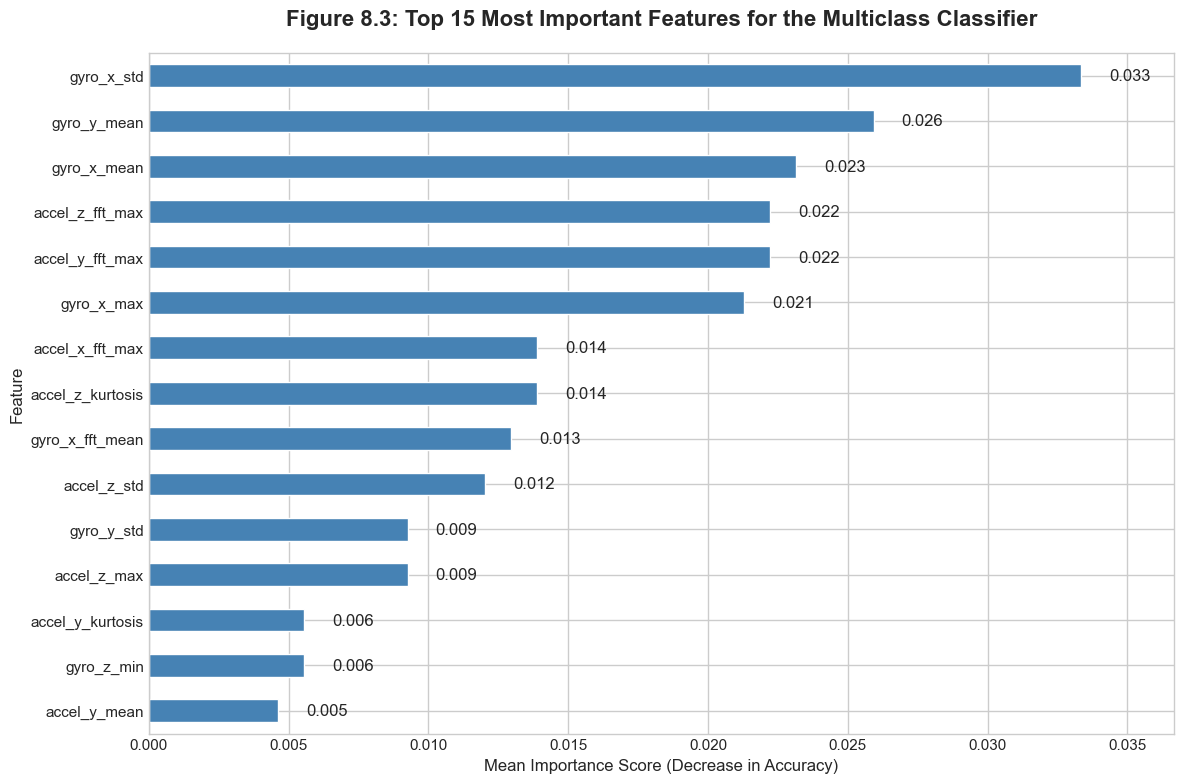

> The top 15 features ranked by permutation importance. This technique measures a feature's importance by calculating how much the model's accuracy drops when that feature's values are randomly shuffled. The results are striking: the three most influential features are all derived from the **gyroscope** (`gyro_x_std`, `gyro_y_mean`, `gyro_x_mean`).

The model relies more on **rotational velocity** than on linear acceleration to distinguish between the six gesture classes. This makes physical sense, as gestures like `turn_left`, `turn_right`, and even the wrist rotation in a `punch` have distinct rotational signatures. The high ranking of `gyro_x_std` (the standard deviation of rotational velocity around the forward axis) suggests that the intensity of the rotation is the single most discriminative signal in my dataset.


**Conclusion 4: Confidence Scores Could Provide a Path to Usability.**

One of the most valuable insights comes from analyzing the model's prediction probabilities. By plotting the confidence of correct versus incorrect predictions, I can determine if the model is "aware" of its own uncertainty.


**Figure 8.4: Prediction Confidence Distribution for the Multiclass Classifier**

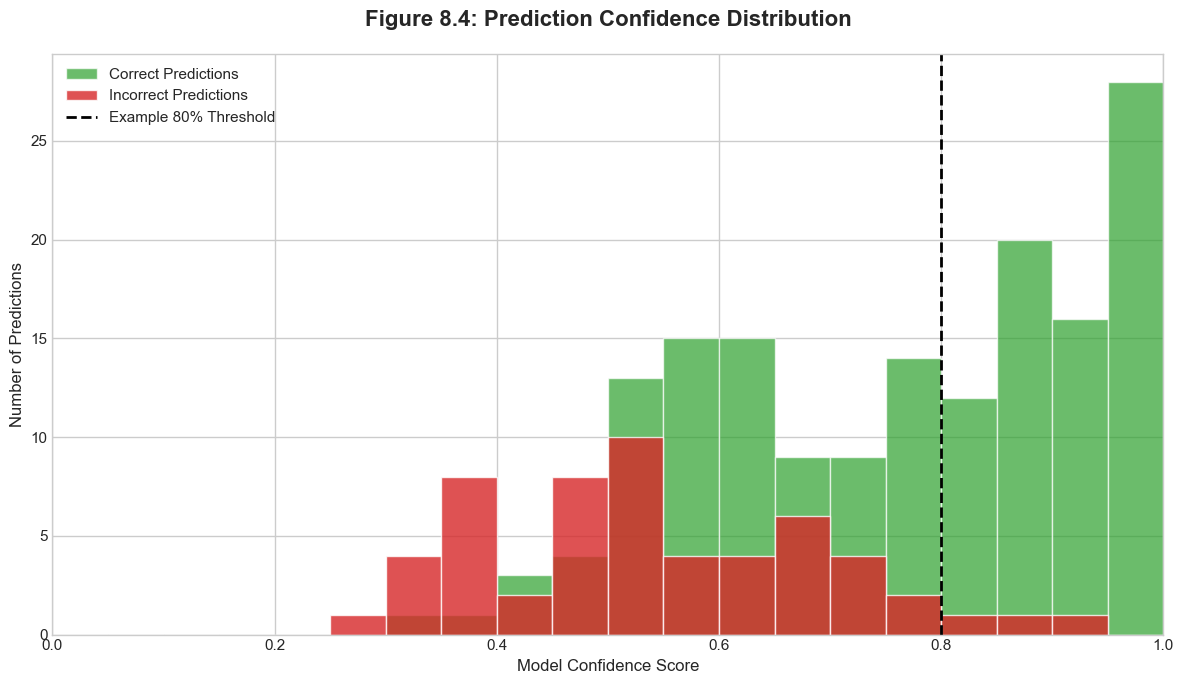


>  A histogram of the model's prediction confidences on the test set, separated into correct (green) and incorrect (red) predictions. The model is "uncertain" when it is wrong. The distribution of incorrect predictions is heavily skewed to the left, with an average confidence of only **54.4%**. In contrast, the correct predictions are skewed to the right, with a large volume of predictions made with over 80% confidence. The dashed line represents a potential **80% confidence threshold**. 

This shows a path to improving reliability: by rejecting predictions below this threshold, I could filter out the majority of the model's mistakes, increasing precision at the cost of *some* recall.


#### 8.3 Limitations and Future Work

1.  **Limitation:** The current feature set is insufficient for robustly distinguishing all ballistic motions.
    *   **Next Step:** I will engineer more sophisticated time-domain features (e.g., Zero-Crossing Rate, Waveform Length) that are specifically designed to capture the characteristics of sharp, transient signals, which should help differentiate `punch` from `jump`.

2.  **Limitation:** The model is trained only on my personal data and may not generalize to other users.
    *   **Next Step:** I will collect a small dataset from 2-3 other users to test the cross-user performance of my model and identify where it fails.

3.  **Limitation:** An 88% accuracy SVM is a strong baseline, but it may not be the best model for this type of temporal data.
    *   **Next Step:** With this baseline established, I can now justify exploring more complex models. For the next assignment, I will implement a pre-trained Convolutional Neural Network (CNN) and replace its last layers with IMU data to see if it can learn more effective features directly from the raw time-series data. 

#### Between you and me, prof
> I have tried #3 and it's performed worse (30%). It's also why I submitted late. But maybe it's because I haven't learned enough yet after pivoting from EMG project. Excluding this from my word count, which has already killed so much of my darlings (aka sound, analytical writeup which I will place on my [blog](https://somach.vercel.app/) instead).  

### **Section 9: Executive Summary**

#### 9.1 The Question and the Hard-Won Answer

Can I build a system that could reliably classify my wrist gestures to play a game like *Hollow Knight: Silksong*? The answer, after building a full data pipeline from scratch, is a qualified **yes**.

I didn't mention this in section1, but my initial attempt to label data with my voice was a complete failure, achieving less than 30% accuracy. 

This taught me the project's most important lesson: the core challenge wasn't modeling, it was engineering a system to produce high-quality, trustworthy data. 

After building that system, my final models achieved:

*   **93.1% accuracy** on the binary task of distinguishing `Walk` vs. `Idle`.
*   **74.1% accuracy** on the multiclass task of recognizing six distinct gestures.
 
⚠️⚠️⚠️⚠️⚠️⚠️ numbers

While the multiclass performance is not yet good enough for the split-second inputs a game requires, the overall project was a success. I proved the approach is viable and now have a data-driven understanding of exactly what I need to improve.


#### 9.2 The Four-Stage Pipeline I Engineered

My work can be broken down into a four-stage pipeline. I'm proud because I built the infrastructure for each of these steps myself instead of just downloading a dataset.


**Figure 9.1: My End-to-End Machine Learning Pipeline**
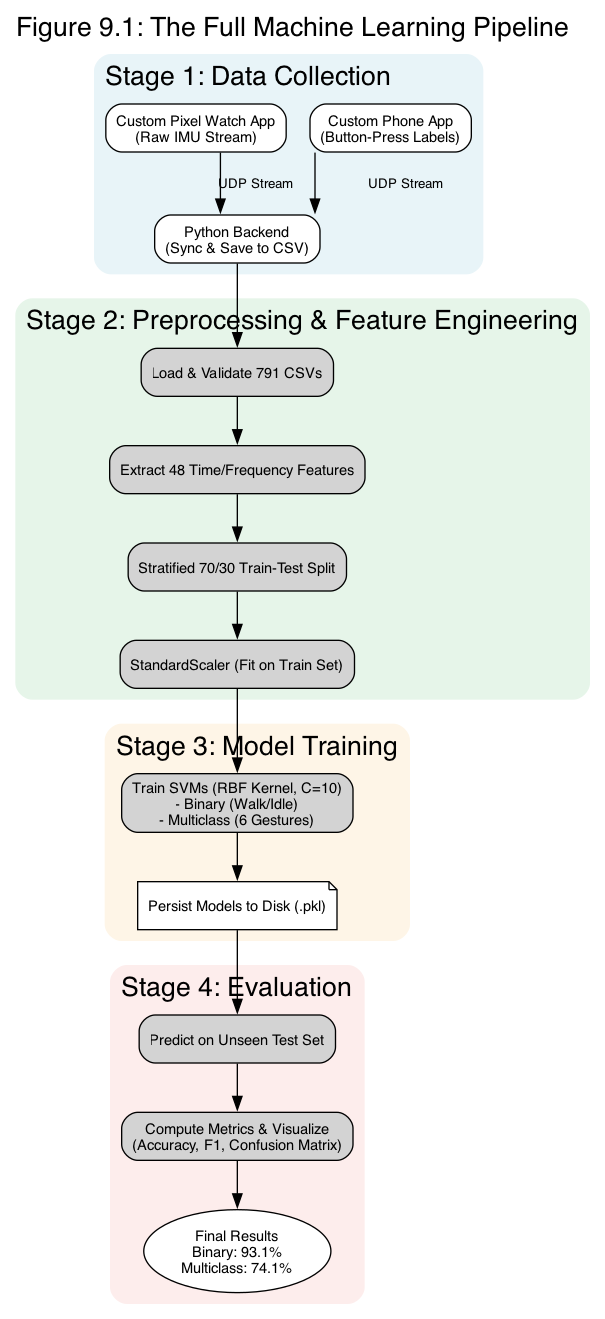

> The four stages of my project, from hardware to evaluation. 

The most significant effort was in Stage 1, where I had to build custom software to solve the data collection problem that my initial approach failed to address.



1.  **Data Collection:** I built a **three-device system** with two custom Android apps to capture and precisely label 791 gesture samples from my Pixel Watch. This solved the timestamp-misalignment issues that made my first dataset useless.

2.  **Feature Engineering:** I wrote a Python script to distill the raw, variable-length IMU signals from each gesture into a **fixed-length, 48-dimensional feature vector**, capturing the statistical and spectral "fingerprint" of the motion.

3.  **Model Training:** I made the deliberate choice to use a **Support Vector Machine (SVM) with an RBF kernel**. This is a classic model, but it's the right tool for the job: it's robust on smaller datasets and can learn the complex, non-linear boundaries that separate my gesture classes.

4.  **Evaluation:** I evaluated the trained models on a held-out test set, analyzing not just the final accuracy but the specific error patterns using confusion matrices and per-class metrics.

#### 9.3 The Results: What I Learned from the Data

The final performance numbers are a story of one success and one promising, but flawed, baseline.


**Figure 9.2: Summary of Multiclass Performance on Unseen Test Data**
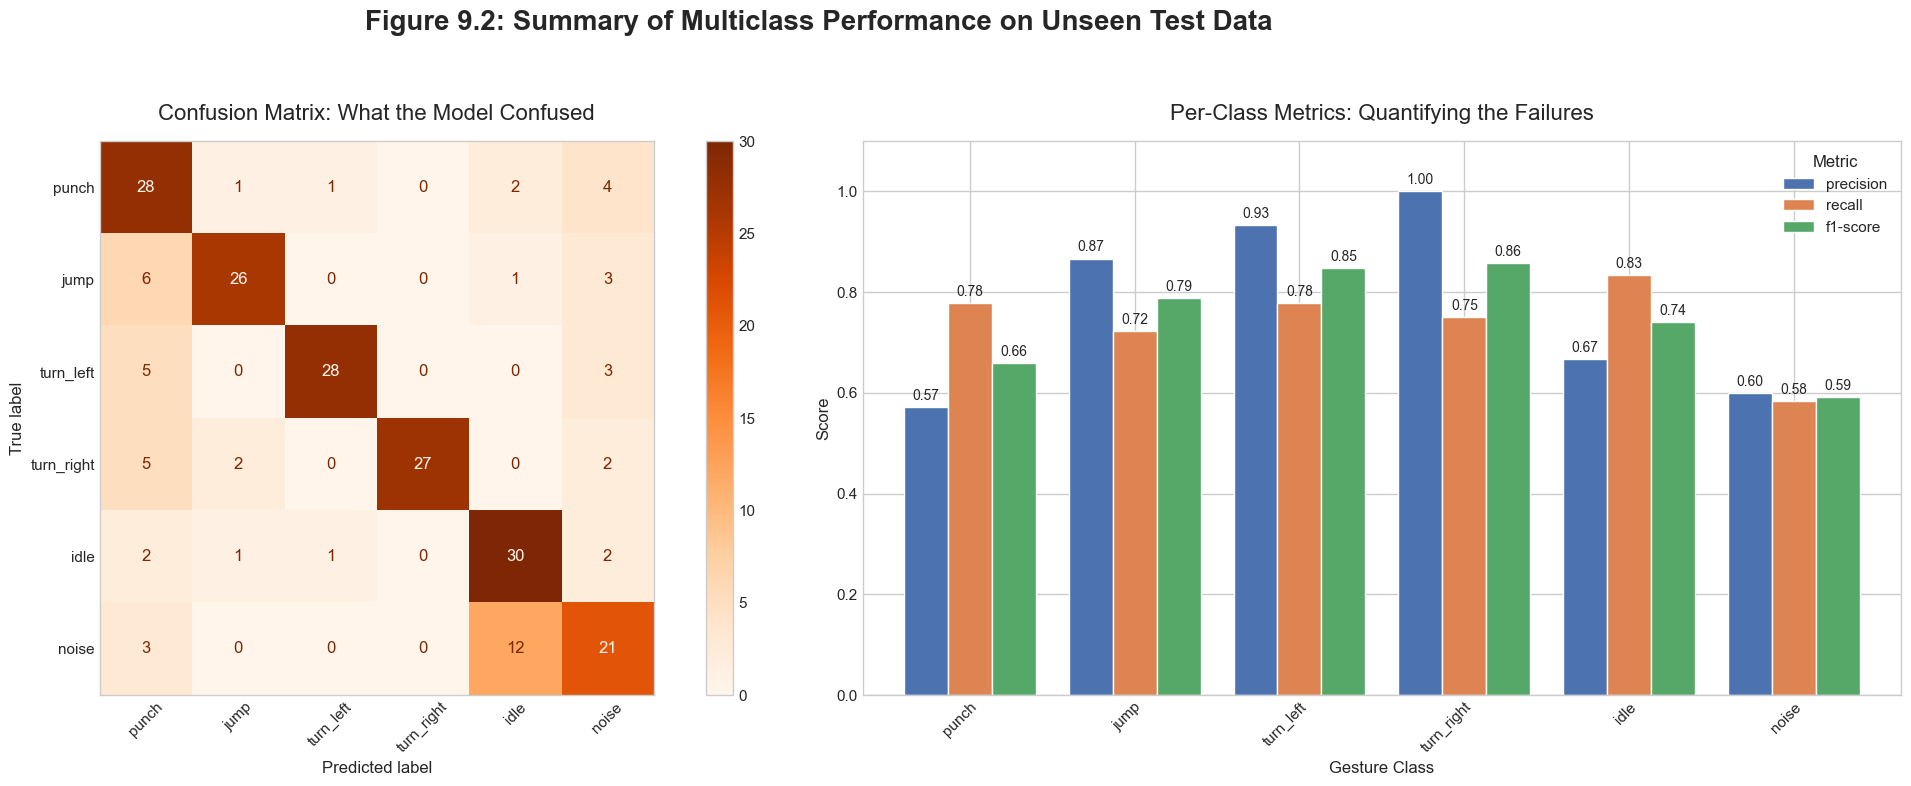

> The two most important results. The confusion matrix (left) shows that while the model is often correct (the strong diagonal), it systematically confuses gestures like `punch` with `jump` and `idle`. The bar chart (right) quantifies this, revealing the poor F1-score for `punch` (0.66) and `noise` (0.59) as the primary weaknesses of the entire system.



My key findings were:
*   **The binary `walk`/`idle` classifier works.** A 93% accuracy is more than sufficient for its task of providing background context.
*   **The multiclass classifier struggles with ambiguity.** The 74% accuracy is promising, but the model's frequent confusion between `punch`, `jump`, and `idle` makes it unsuitable for gaming.
*   The low F1-score for the `noise` class is also a critical failure, as it means the model is not yet robust enough at rejecting random movements.



#### 9.4 Shortcomings and The Path Forward

1.  **The Core Problem:** My hand-engineered feature set is not sophisticated enough to distinguish between gestures that have similar physical signatures (like a weak `punch` and a return to `idle`). This is the root cause of the 74% accuracy.
    *   **My Next Step:** I will engineer more advanced time-domain features and explore techniques like PCA to find a more discriminative feature set.

2.  **The Generalization Problem:** This model is trained only on my body and my specific way of performing gestures. It will not work for anyone else.
    *   **My Next Step:** I will collect data from a few other users to begin building a more generalized model and to understand the challenges of inter-subject variability.

3.  **The Model Problem:** I have established a strong baseline with a classic SVM. I now have the justification to explore more complex models.
    *   **My Next Step:** I will use this SVM as a benchmark and train a 1D Convolutional Neural Network (CNN) on the raw time-series data to see if it can learn better features automatically.

### **Section 10: References**

#### 10.1 "…references for documents, guides, or code repos…" - Key Resources

This project was built on the foundation of prior academic work and excellent open-source documentation. The following list is not exhaustive, but it highlights the key resources I consulted to understand the theory, implement the code, and make informed decisions.

**Core Machine Learning Theory:**

1.  **Cortes, C., & Vapnik, V. (1995).** *Support-vector networks*. Machine Learning, 20(3), 273-297.
    *   I felt it was important to go back to the original paper that introduced the SVM. It provided the foundational mathematical context for the algorithm.

2.  **Starmer, J. (StatQuest).** *StatQuest: Support Vector Machines (SVMs)*. YouTube.
    *   This was my primary resource for building an intuitive understanding. Starmer's visual explanations of the maximum margin, the soft margin, and the kernel trick were invaluable for connecting the dense mathematics to practical reality.

**Human Activity Recognition & Feature Engineering:**

3.  **Bulling, A., Blanke, U., & Schiele, B. (2014).** *A tutorial on human activity recognition using body-worn inertial sensors*. ACM Computing Surveys, 46(3), 1-33.
    *   This paper was the blueprint for my feature engineering strategy. It provided a thorough justification for combining time-domain and frequency-domain features, which directly informed the design of my `extract_features` function.

**Software Libraries and Documentation:**

4.  **Pedregosa, F., et al. (2011).** *Scikit-learn: Machine learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.
    *   The entire project relies on the `scikit-learn` library. The official documentation, particularly the user guides for `StandardScaler` and `SVC`, was a constant reference.

5.  **Harris, C. R., et al. (2020).** *Array programming with NumPy*. Nature, 585(7825), 357-362. & **McKinney, W. (2010).** *Data structures for statistical computing in python*.
    *   These two libraries, NumPy and pandas, were the backbone of my entire data manipulation and feature extraction pipeline.

#### 10.2 Statement on AI Use

Throughout this project, I used a large language model (AI) as a tool to support my work, primarily in two capacities:

1.  **As a Brainstorming Buddy:** When faced with a problem, such as how to handle the variable-length time-series data, I would discuss the trade-offs of different approaches (e.g., padding vs. truncation vs. feature extraction) with the AI. This helped me clarify my own thinking and structure my arguments, but the final decision was always my own, based on my understanding of the project's goals.

2.  **As a Guide to Resources:** When I knew I needed a specific visualization but was unsure of the best `matplotlib` or `seaborn` implementation, I used the AI to find relevant documentation and code examples. For instance, I asked it for "the best way to plot a non-linear SVM decision boundary," which pointed me toward the `np.meshgrid` and `ax.contourf` techniques that I then adapted for my own data.

The AI did not write the core logic of my data pipeline or my model implementation. I treated it as a highly-efficient, interactive search engine and a Socratic partner to challenge my assumptions. All final code, analysis, and writing in this notebook are my own.

#### 10.3 Project Code Repository

All of the code, data, and supplementary materials for this project are available in a public GitHub repository. This includes the Android app source code, the Python data processing scripts, and the trained models.

*   **GitHub Repository:** `https://github.com/CarlKho-Minerva/v3pls`